<style>
:root{--navy:#102a43;--blue:#2563eb;--teal:#0f9d91;--red:#dc2626;--ink:#243b53;--soft:#f1f5f9}
.hero{padding:34px;border-radius:20px;background:linear-gradient(135deg,var(--navy),#1d4ed8);color:white;box-shadow:0 12px 28px #102a4333;margin-bottom:22px}
.hero h1{font-size:2.35rem;margin:.2rem 0}.hero p{font-size:1.05rem;opacity:.92}.tag{display:inline-block;padding:6px 12px;border-radius:999px;background:#ffffff22;border:1px solid #ffffff55;font-weight:700;letter-spacing:.05em}
.section{border-left:6px solid var(--teal);padding:7px 16px;margin:30px 0 14px;background:linear-gradient(90deg,#e6fffa,white);border-radius:0 12px 12px 0}.section h2{color:var(--navy);margin:.2rem 0}
.insight,.warning,.method{padding:14px 17px;border-radius:12px;margin:14px 0}.insight{background:#ecfdf5;border:1px solid #6ee7b7}.warning{background:#fff7ed;border:1px solid #fdba74}.method{background:#eff6ff;border:1px solid #93c5fd}
.metric-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(150px,1fr));gap:10px;margin:14px 0}.metric{background:white;border:1px solid #dbeafe;border-radius:12px;padding:13px;text-align:center;box-shadow:0 4px 12px #102a4311}.metric b{font-size:1.35rem;color:var(--blue)}
.footer{margin-top:32px;padding:18px;text-align:center;border-top:1px solid #cbd5e1;color:#52667a}
</style>

<div class="hero">
  <span class="tag">ENTREGA FINAL · 100%</span>
  <h1>Laboratorio 5 · Minería de Textos y Análisis de Sentimientos</h1>
  <p>Clasificación reproducible de tweets sobre desastres reales</p>
  <p><b>Universidad del Valle de Guatemala</b> · Data Science · Sección 10 · Grupo 1</p>
  <p>Jorge Gabriel Palacios Sales — 231385 · Pablo Daniel Barillas Moreno — 22193 · Roberto Emiliano Otoniel — 23968</p>
</div>

<div class="section"><h2>1 · Propósito y preguntas de análisis</h2></div>

El objetivo es identificar si un tweet describe un desastre real (`target = 1`) o si utiliza lenguaje similar fuera de ese contexto (`target = 0`). El flujo responde cuatro preguntas: ¿qué vocabulario distingue las clases?, ¿qué modelo generaliza mejor?, ¿los desastres se expresan con mayor negatividad? y ¿esa negatividad mejora la predicción?

<div class="method"><b>Protocolo reproducible.</b> Todas las comparaciones utilizan una división estratificada 80/20 y <code>random_state=42</code>. Las cifras se leen de archivos generados por los scripts del repositorio; no se escriben manualmente.</div>

In [1]:
from pathlib import Path
import json, sys
import joblib
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from lab5_text.analysis import validate_dataset
from lab5_text.final_model import classify_raw_tweet
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

TABLES, FIGURES = ROOT / "outputs" / "tables", ROOT / "outputs" / "figures"
pd.set_option("display.max_colwidth", 110)

TABLE_STYLES = [
    {"selector":"th", "props":[("background-color","#102a43"),("color","white"),("font-weight","700"),("text-align","left")]},
    {"selector":"td", "props":[("border-bottom","1px solid #dbeafe"),("padding","8px")]},
    {"selector":"tr:nth-child(even)", "props":[("background-color","#f8fafc")]},
]
def show_table(frame, precision=3):
    display(frame.style.format(precision=precision).set_table_styles(TABLE_STYLES).hide(axis="index"))

summary = json.loads((TABLES / "resumen_final.json").read_text(encoding="utf-8"))
print("Entorno y utilidades cargados correctamente.")

Entorno y utilidades cargados correctamente.


<div class="section"><h2>2 · Datos</h2></div>

Se usa `train.csv` de la competencia *Natural Language Processing with Disaster Tweets*. Sus columnas son `id`, `keyword`, `location`, `text` y `target`. `keyword` y `location` pueden faltar; `text` y `target` son indispensables. `test.csv` no se emplea para evaluar porque no incluye la etiqueta objetivo.

Filas: 7,613 · Columnas: 5 · Duplicados exactos: 0
Valores faltantes por columna:


,id,keyword,location,text,target
faltantes,0,61,2533,0,0


target,tweets,categoria,porcentaje
0,4342,No desastre,57.034
1,3271,Desastre real,42.966


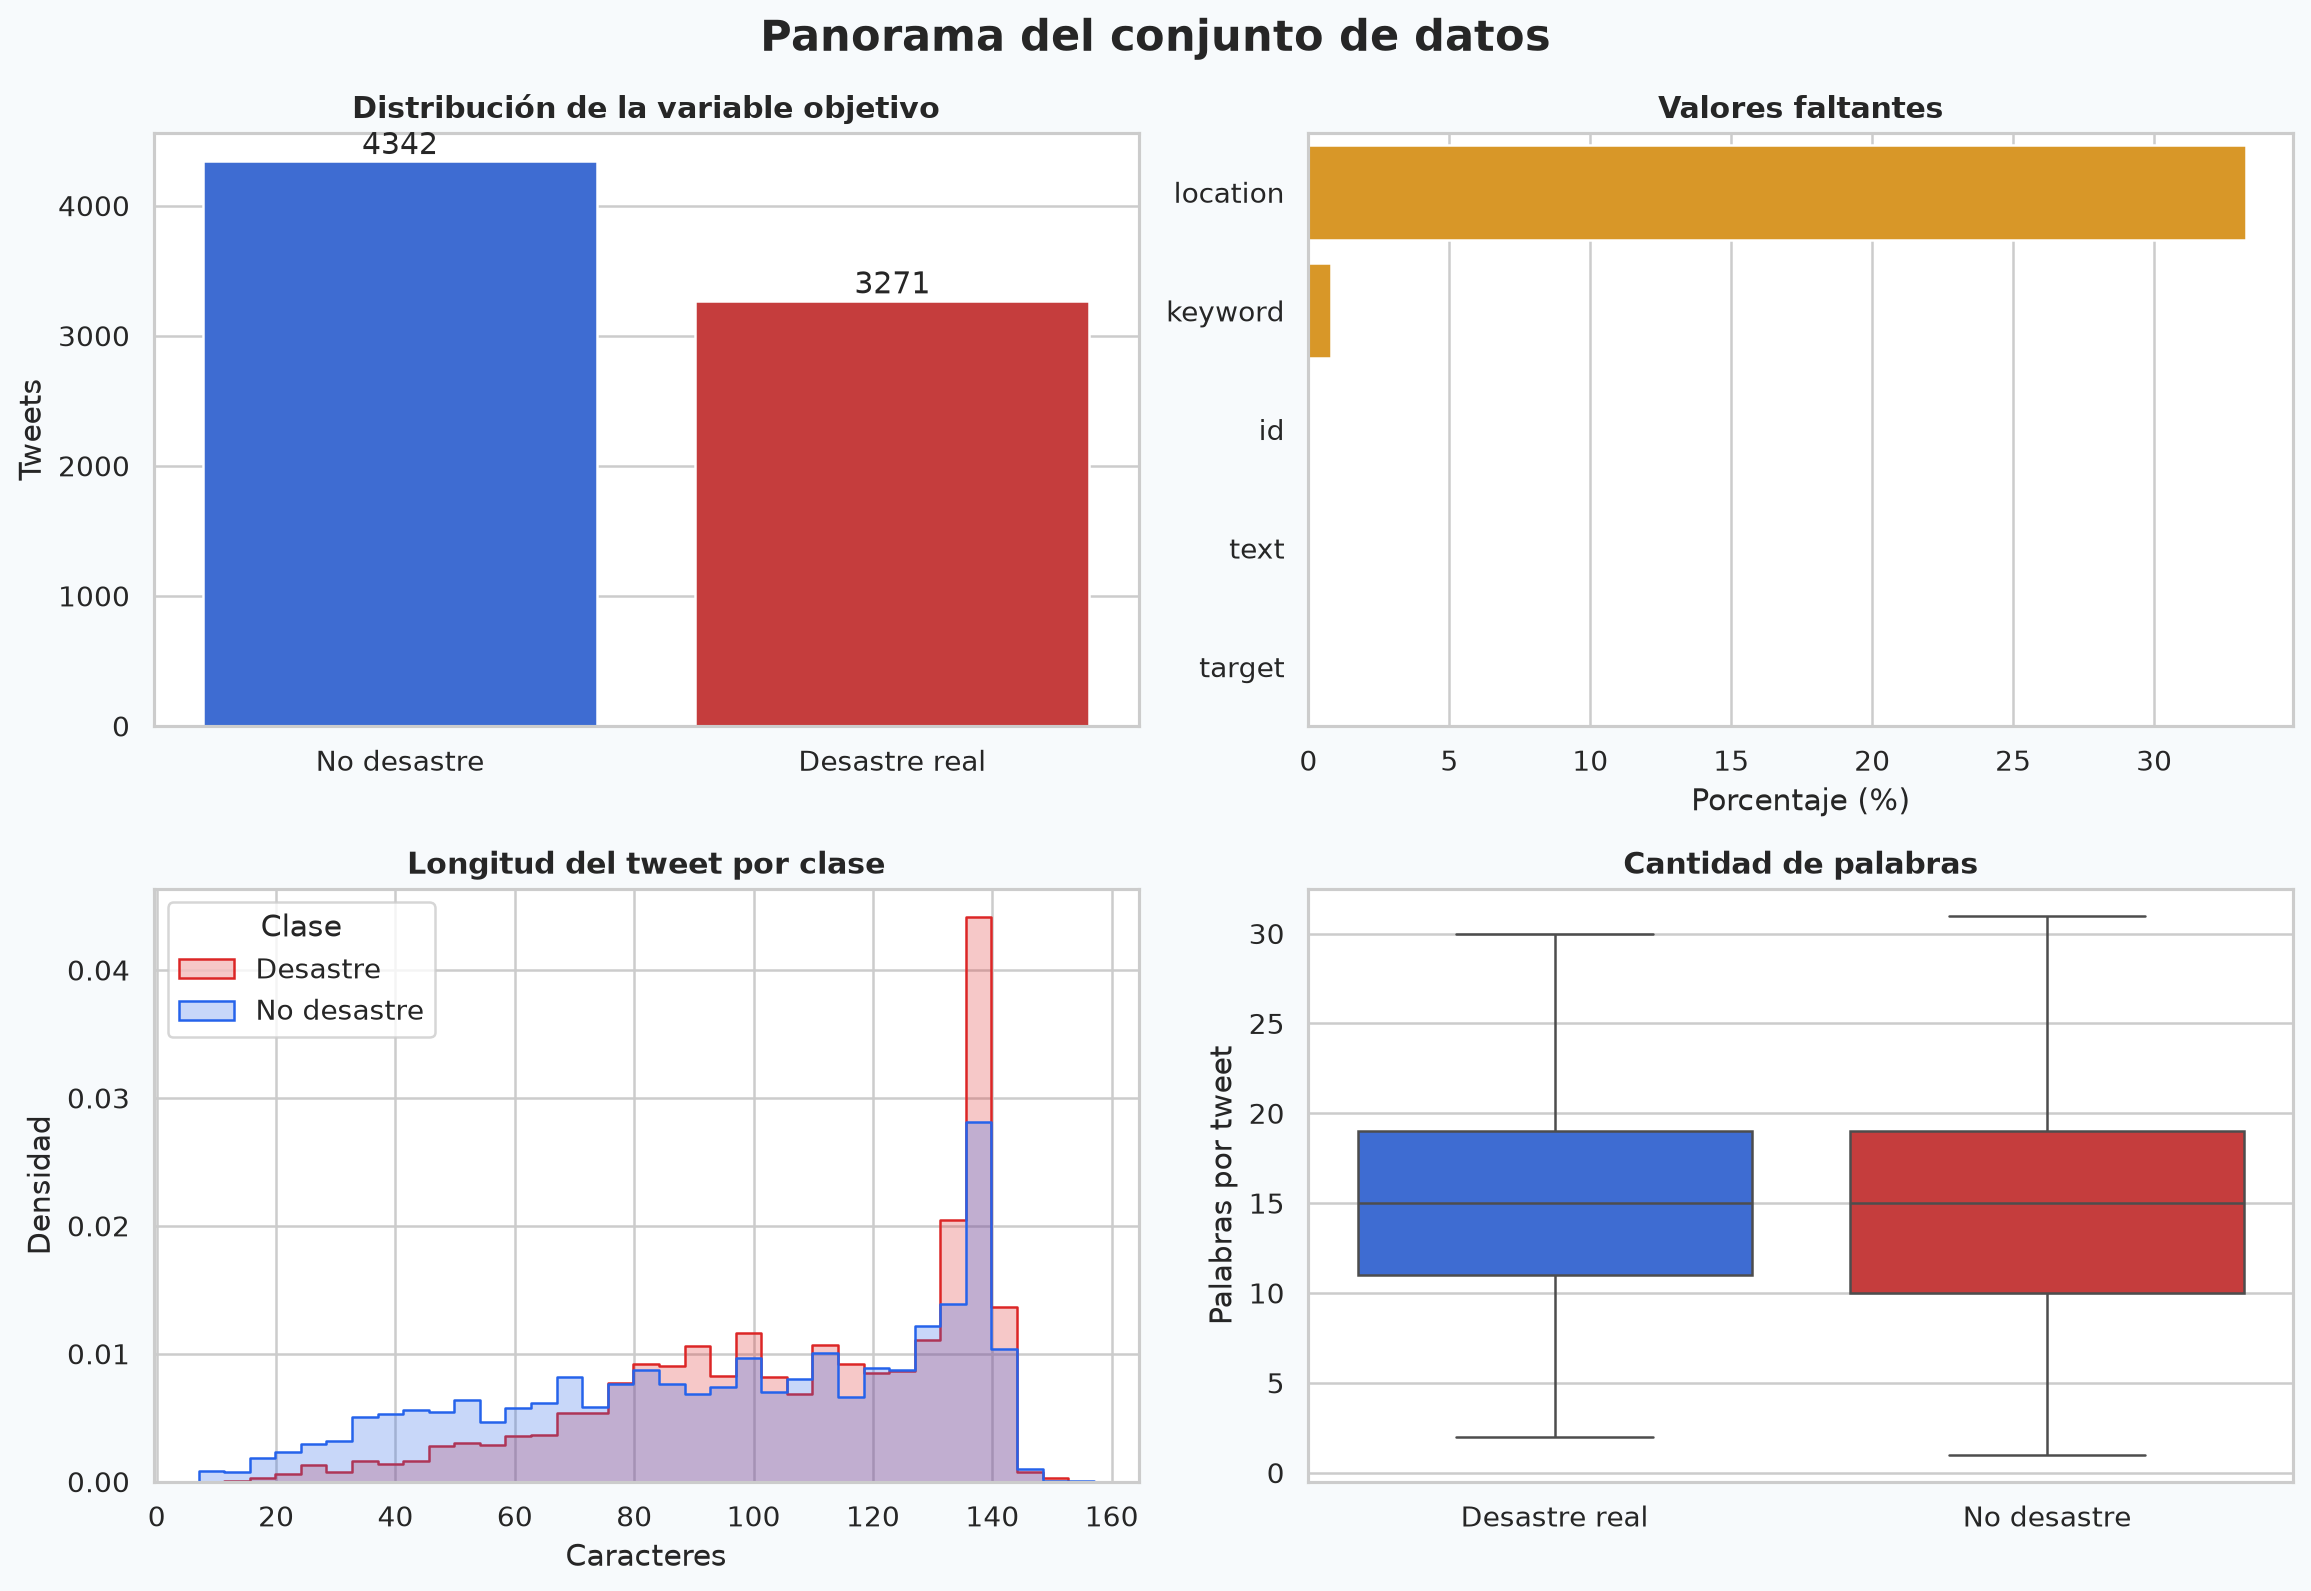

In [2]:
data = pd.read_csv(ROOT / "data" / "raw" / "train.csv")
validate_dataset(data)
distribution = pd.read_csv(TABLES / "distribucion_target.csv")
print(f"Filas: {len(data):,} · Columnas: {data.shape[1]} · Duplicados exactos: {data.duplicated().sum()}")
print("Valores faltantes por columna:")
display(data.isna().sum().to_frame("faltantes").T)
show_table(distribution)
display(Image(filename=str(FIGURES / "eda_panorama.png"), width=980))

<div class="insight"><b>Lectura.</b> Hay 4,342 tweets sin desastre (57.06%) y 3,271 con desastre (42.94%). El desbalance es moderado; por ello, además de exactitud se reportan precisión, recall, F1, F1 macro y ROC–AUC.</div>

<div class="section"><h2>3 · Limpieza y preprocesamiento</h2></div>

Para modelar se normaliza a minúsculas, se reemplazan URL y menciones por marcadores, se separan hashtags, se eliminan caracteres no informativos y se reducen espacios. Se conserva una segunda versión ligera para VADER, porque negaciones, signos, mayúsculas, emojis y emoticonos aportan información de sentimiento. La lista de palabras vacías se audita de forma explícita para reconocer posibles pérdidas de vocabulario temático.

In [3]:
cleaning = pd.read_csv(TABLES / "ejemplos_preprocesamiento.csv").head(8)
audit = pd.read_csv(TABLES / "auditoria_limpieza.csv")
stopwords = pd.read_csv(TABLES / "auditoria_stopwords.csv")
show_table(cleaning)
print("Resumen de transformaciones:")
show_table(audit)
print("Palabras de contenido eliminadas por la lista Glasgow (muestra):")
show_table(stopwords.query("es_palabra_de_contenido == True").head(10))

id,target,text,clean_text
1,1,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake allah forgive
6,1,"13,000 people receive #wildfires evacuation orders in California",people receive wildfires evacuation orders california
7,1,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent photo ruby alaska smoke wildfires pours school
8,1,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,rockyfire update california hwy closed directions lake county cafire wildfires
10,1,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",flood disaster heavy rain causes flash flooding streets manitou colorado springs areas
17,1,Haha South Tampa is getting flooded hah- WAIT A SECOND I LIVE IN SOUTH TAMPA WHAT AM I GONNA DO WHAT AM I GONNA DO FVCK #flooding,haha south tampa getting flooded hah wait second live south tampa gonna gonna fvck flooding
18,1,#raining #flooding #Florida #TampaBay #Tampa 18 or 19 days. I've lost count,raining flooding florida tampabay tampa days lost count
19,1,#Flood in Bago Myanmar #We arrived Bago,flood bago myanmar arrived bago


Resumen de transformaciones:


indicador,valor
tweets_totales,7613.000
texto_original_vacio,0.000
texto_limpio_vacio,5.000
palabras_original_promedio,14.904
palabras_limpias_promedio,8.185
tweets_con_url,3971.000
tweets_con_mencion,2009.000
tweets_con_hashtag,1761.000
tweets_con_911,4.000
texto_limpio_con_911,4.000


Palabras de contenido eliminadas por la lista Glasgow (muestra):


palabra_eliminada,tweets_no_desastre,tweets_desastre,log2_razon_desastre,es_palabra_de_contenido
fire,56,136,1.628,True
call,16,14,0.169,True
part,18,14,0.004,True
back,70,32,-0.762,True
well,28,12,-0.834,True
find,19,7,-1.023,True
top,39,13,-1.194,True
show,27,5,-1.967,True
full,81,9,-2.746,True


<div class="warning"><b>Limitación controlada.</b> La lista estándar de scikit-learn contiene términos con posible carga temática, como <code>fire</code>. Se cuantifica esa pérdida y se mantiene fija en todos los modelos para garantizar una comparación justa.</div>

<div class="section"><h2>4 · Frecuencias, n-gramas y contexto</h2></div>

Las frecuencias se calculan por clase para unigramas, bigramas y trigramas. Además del conteo, se conserva la probabilidad condicional dentro de cada clase. Los n-gramas permiten distinguir frases de emergencia de usos figurados que una palabra aislada no separa adecuadamente.

Unigramas más frecuentes en desastres reales


ngram,frecuencia,probabilidad,n,target
not,213,0.009,1,1
news,147,0.006,1,1
disaster,118,0.005,1,1
california,111,0.005,1,1
suicide,110,0.005,1,1
no,108,0.005,1,1
police,107,0.005,1,1
people,105,0.004,1,1
killed,93,0.004,1,1
like,92,0.004,1,1


Bigramas más frecuentes en desastres reales


ngram,frecuencia,probabilidad,n,target
suicide bomber,59,0.006,2,1
northern california,41,0.004,2,1
oil spill,38,0.004,2,1
burning buildings,36,0.004,2,1
suicide bombing,34,0.003,2,1
california wildfire,34,0.003,2,1
bomber detonated,30,0.003,2,1
homes razed,29,0.003,2,1
confirmed mh,29,0.003,2,1
yr old,29,0.003,2,1


Trigramas más frecuentes en desastres reales


ngram,frecuencia,probabilidad,n,target
suicide bomber detonated,30,0.004,3,1
northern california wildfire,29,0.004,3,1
bomber detonated bomb,28,0.004,3,1
homes razed northern,28,0.004,3,1
pkk suicide bomber,28,0.004,3,1
latest homes razed,28,0.004,3,1
old pkk suicide,27,0.004,3,1
razed northern california,27,0.004,3,1
yr old pkk,27,0.004,3,1
families affected fatal,26,0.004,3,1


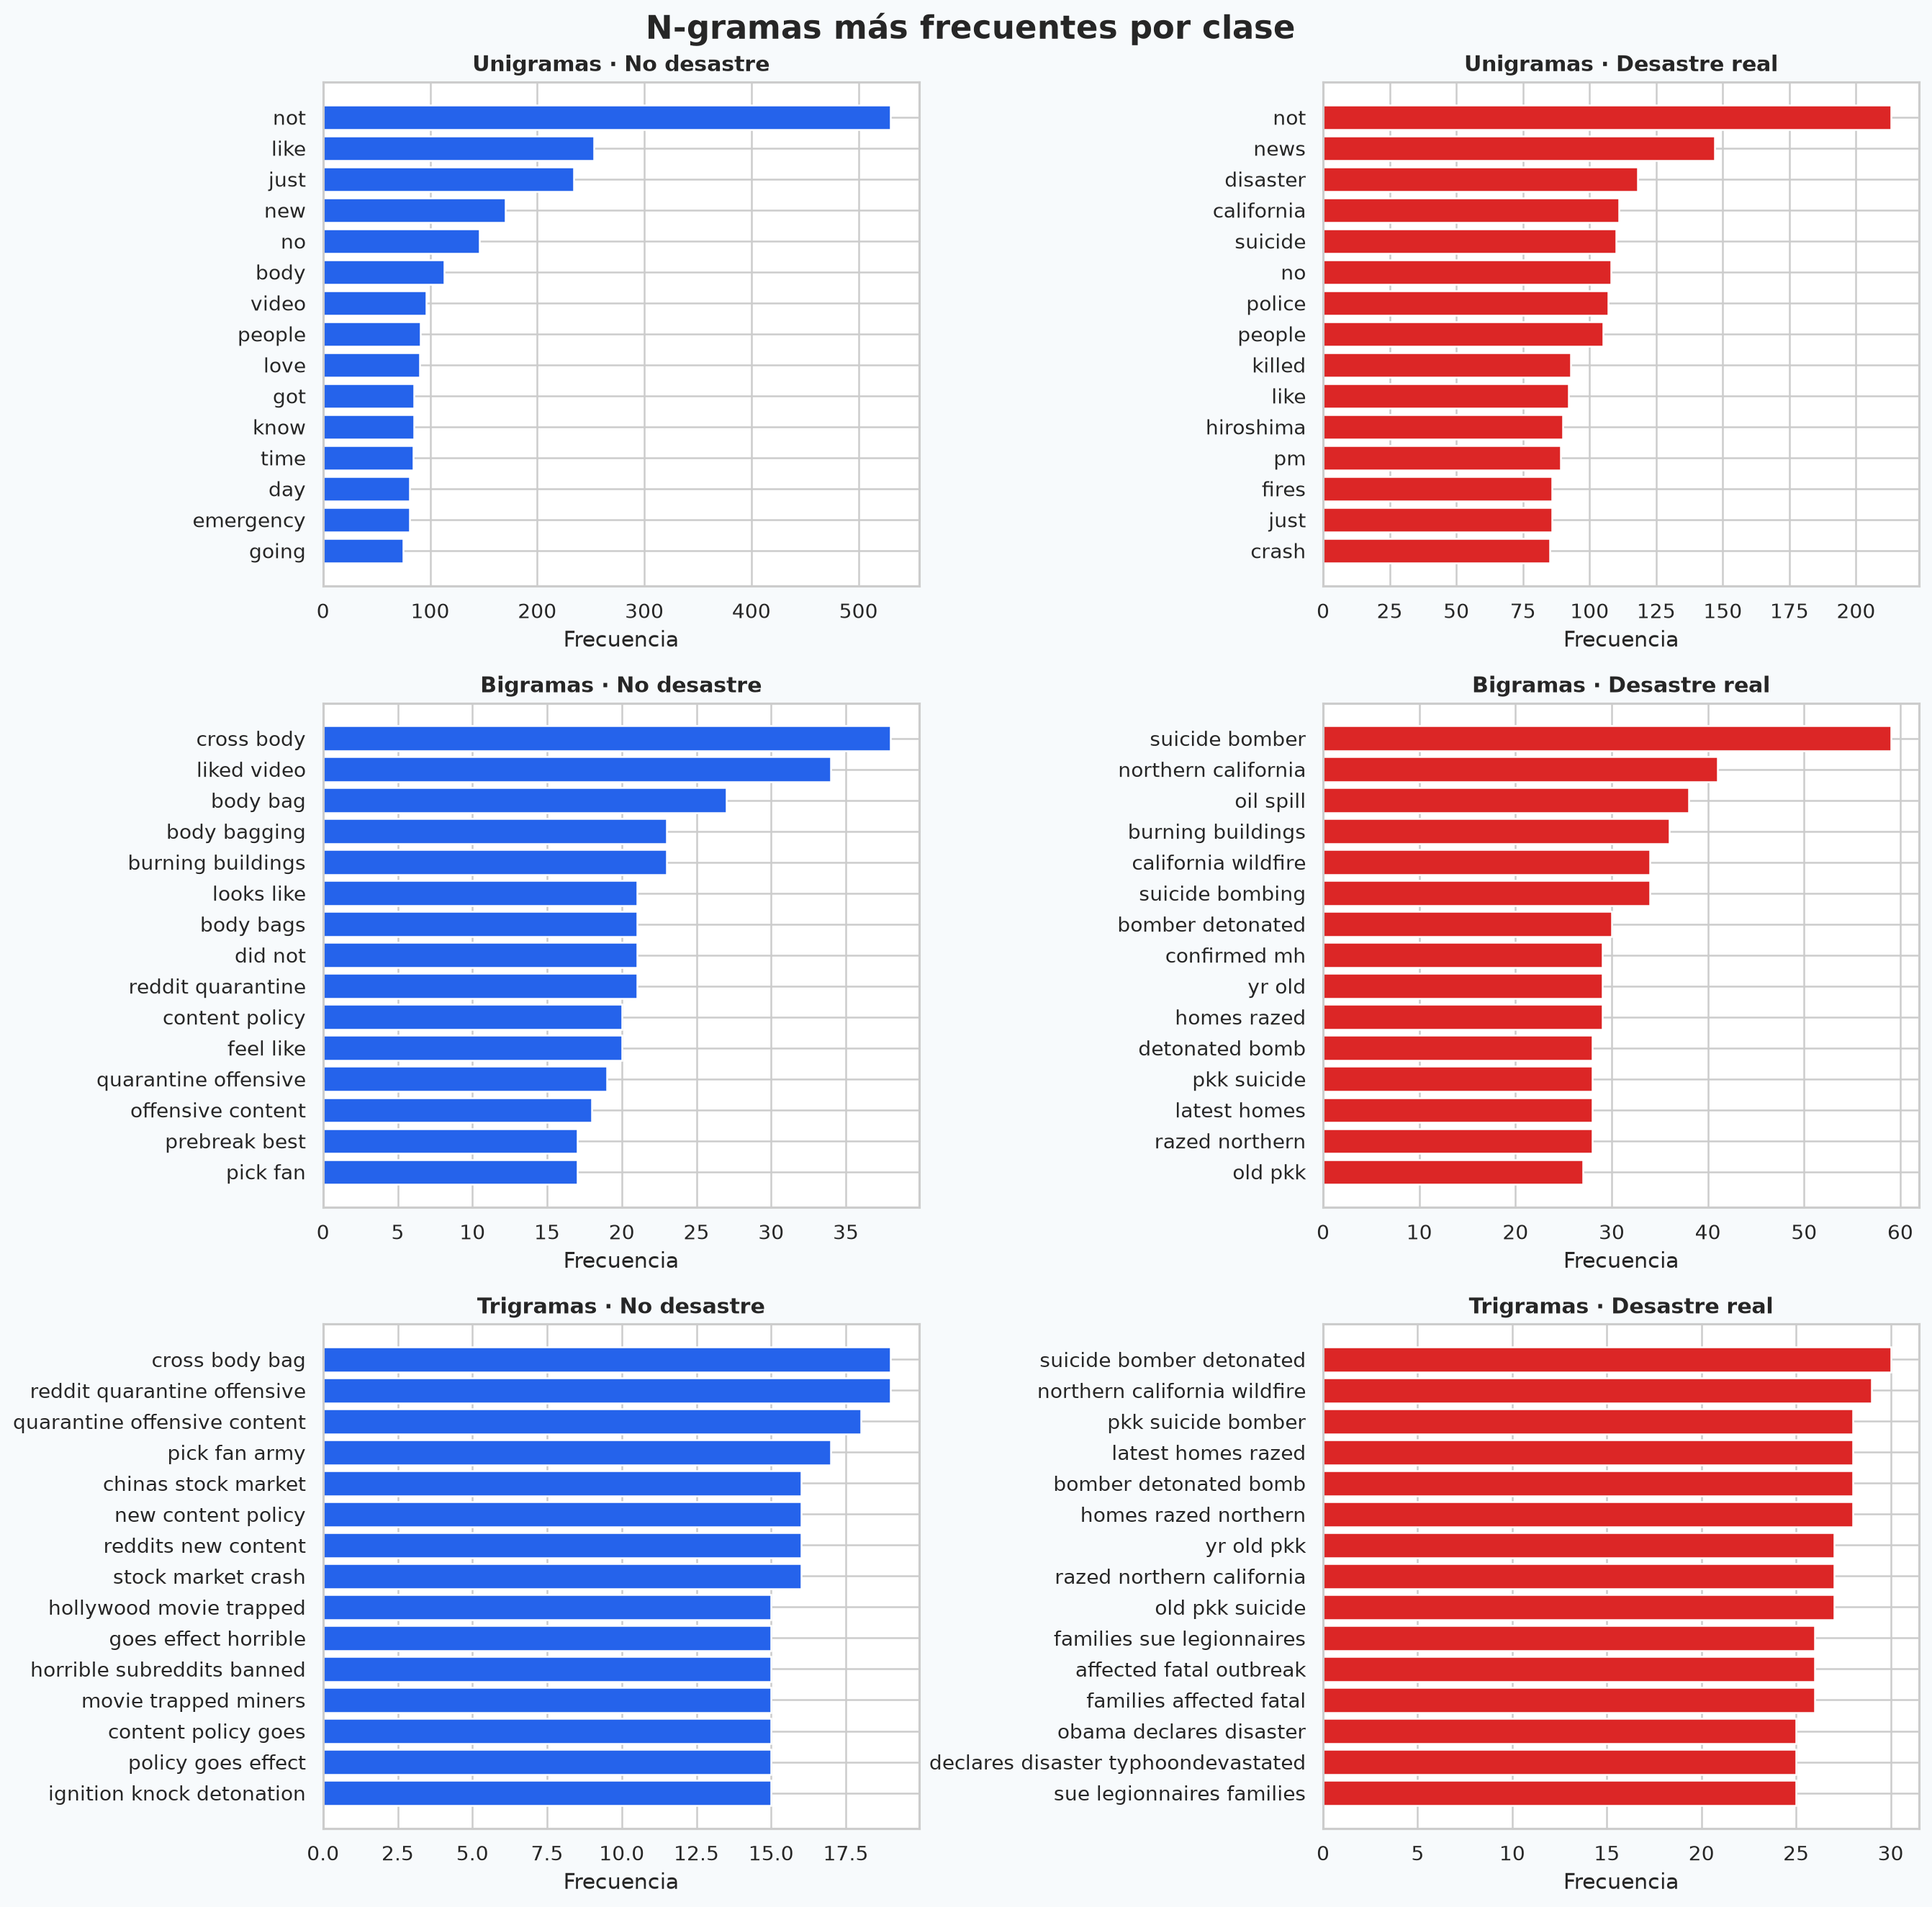

In [4]:
for ngram, label in [("unigramas", "Unigramas"), ("bigramas", "Bigramas"), ("trigramas", "Trigramas")]:
    print(label, "más frecuentes en desastres reales")
    show_table(pd.read_csv(TABLES / f"{ngram}_target_1.csv").head(10))
display(Image(filename=str(FIGURES / "ngramas_por_clase.png"), width=1000))

Las combinaciones relacionadas con advertencias, incendios, evacuaciones y daños aparecen con mayor fuerza en la clase positiva. En la clase negativa predominan expresiones sociales, titulares ambiguos y lenguaje figurado. Las nubes de palabras son descriptivas; la inferencia se apoya en tablas y modelos, no en el tamaño visual de los términos.

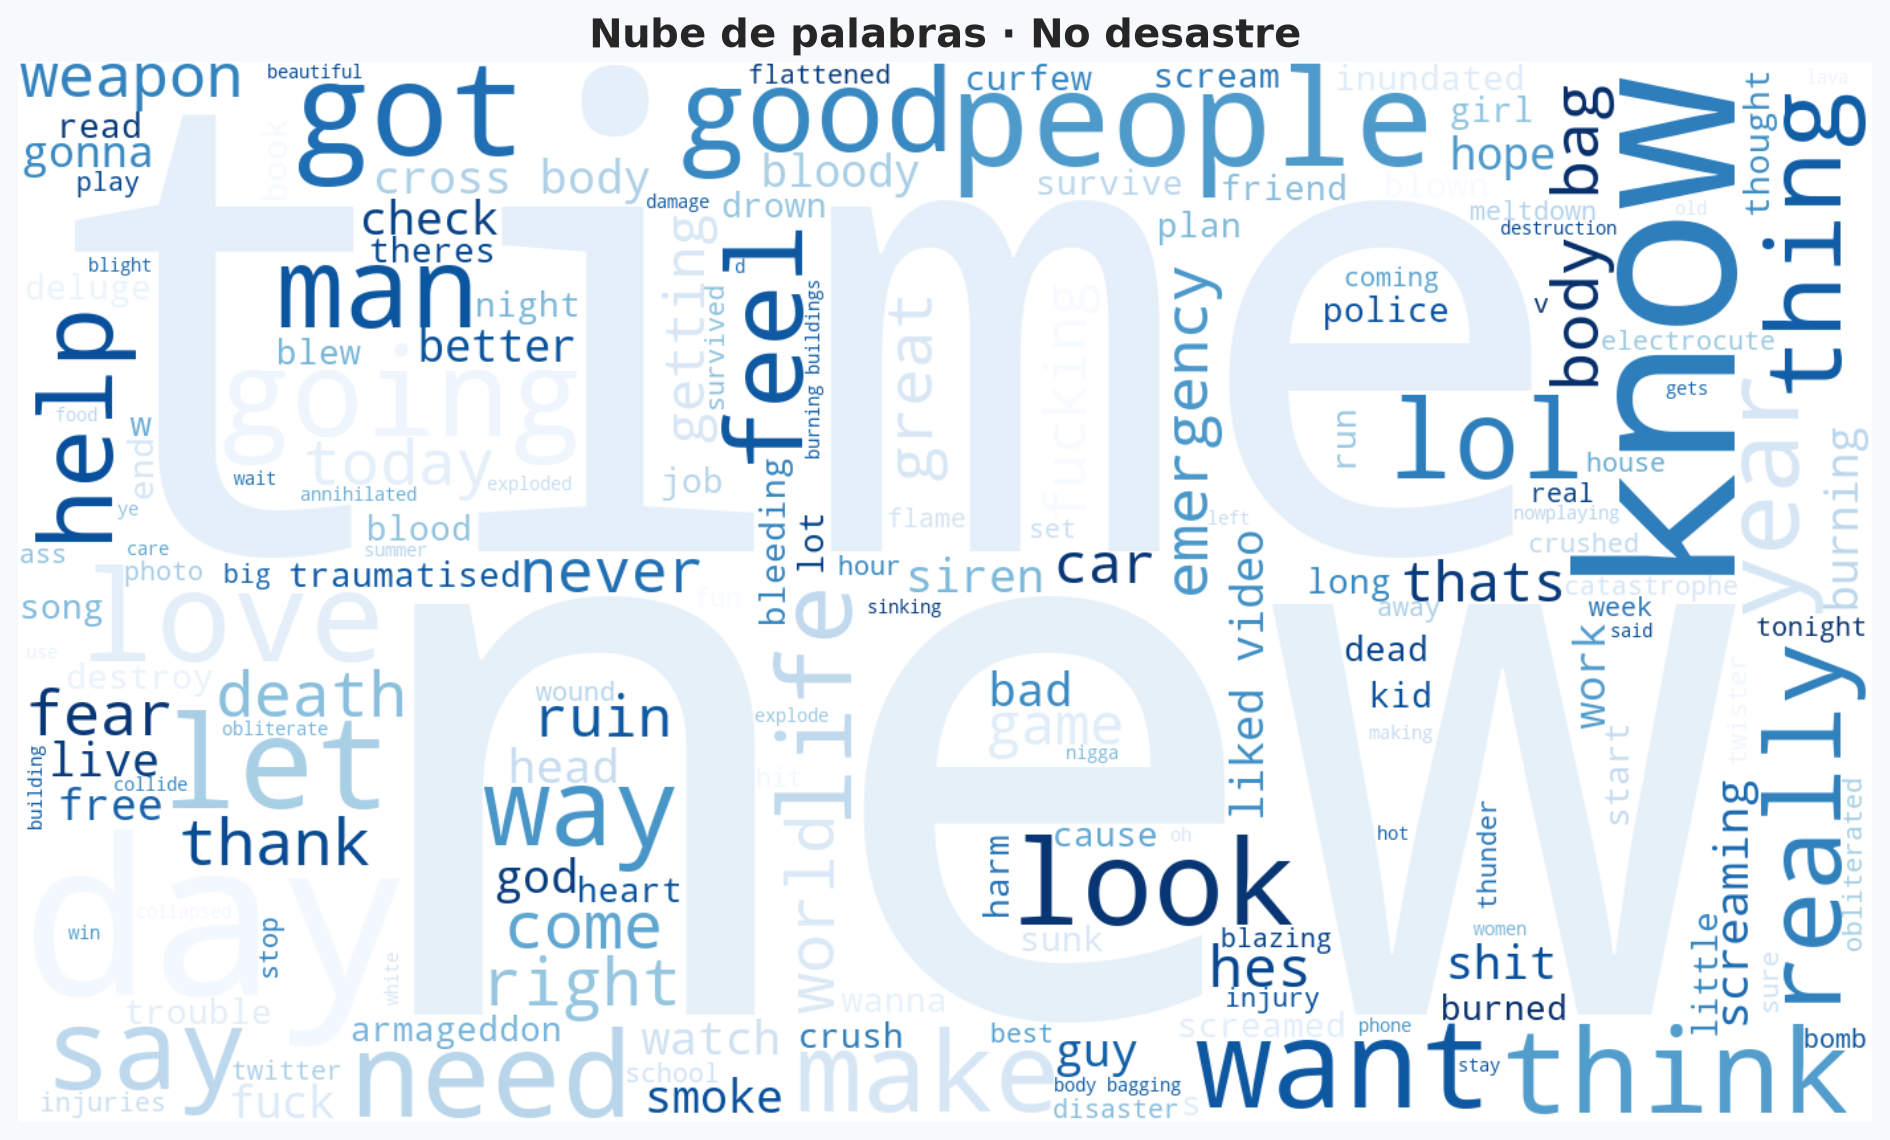

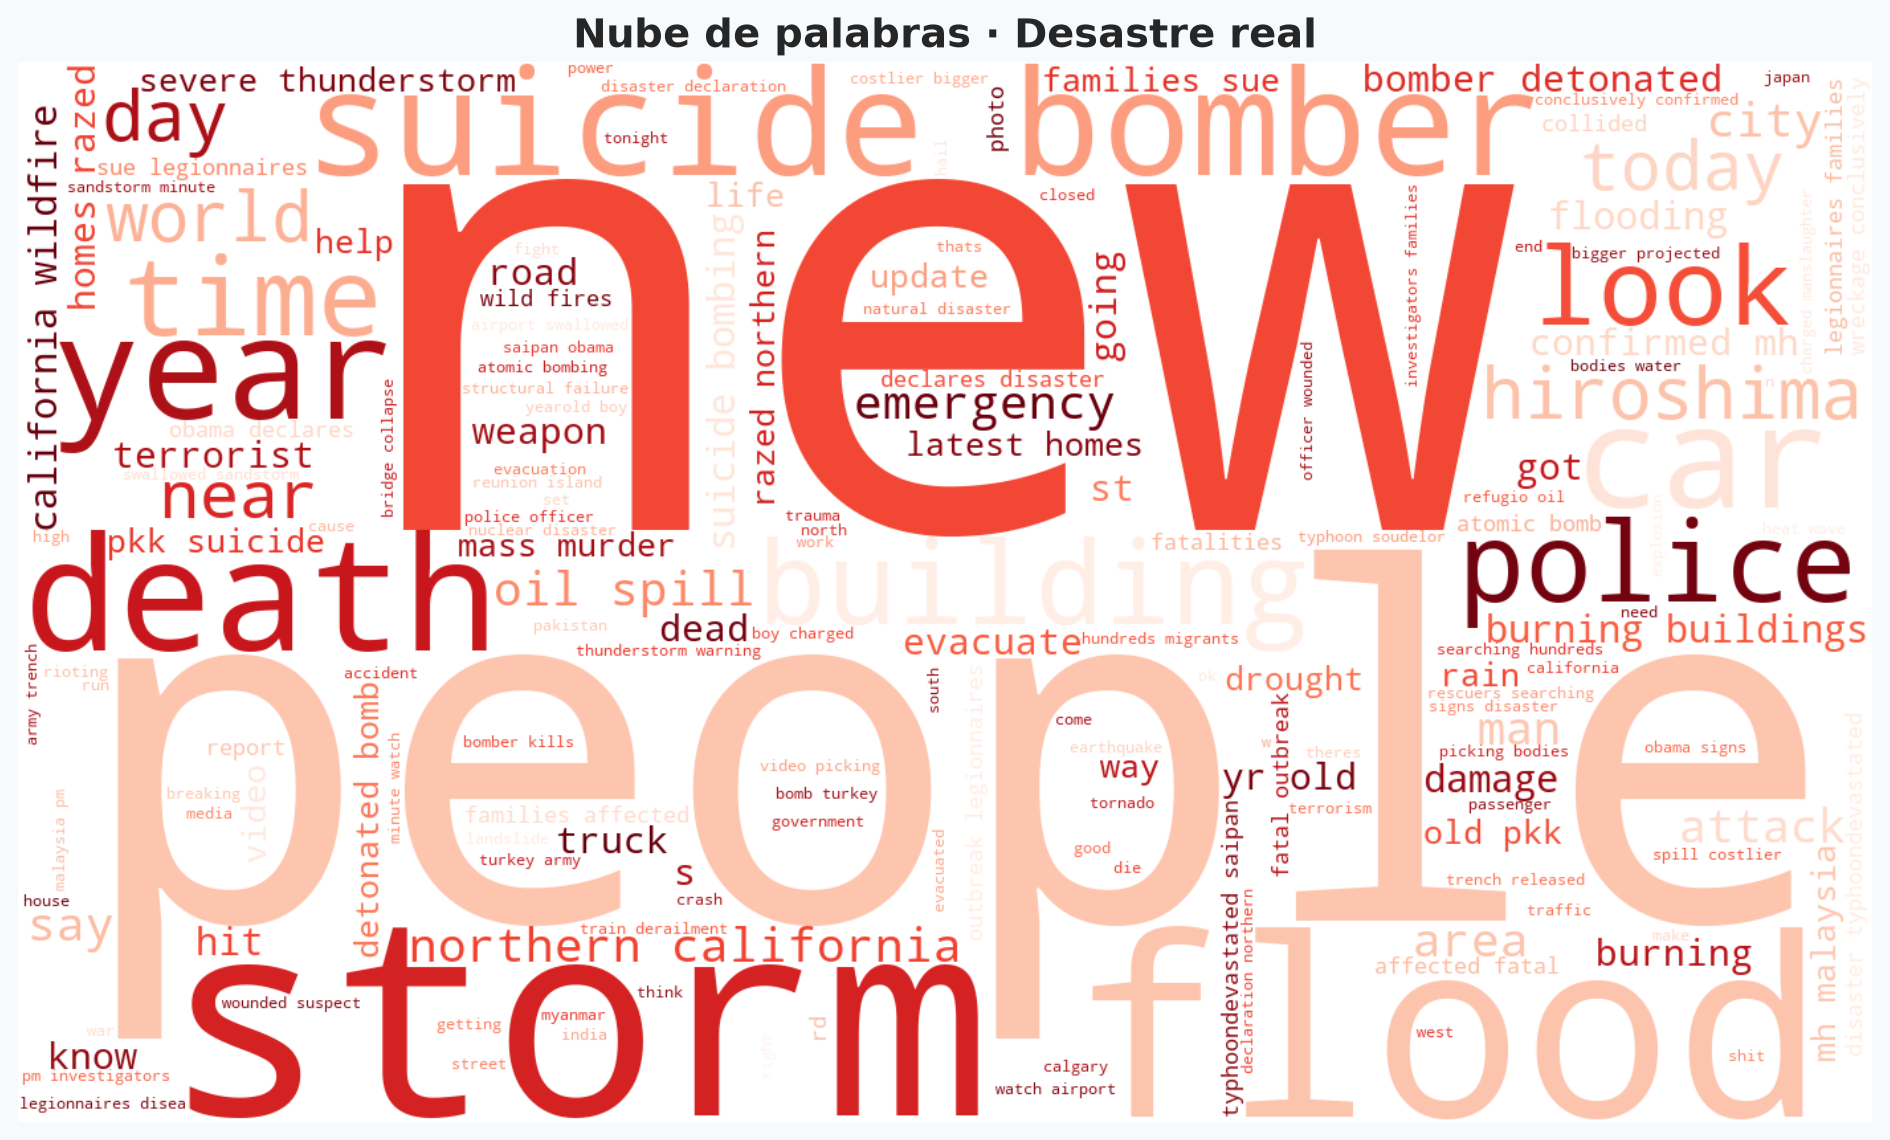

In [5]:
display(Image(filename=str(FIGURES / "nube_palabras_target_0.png"), width=470))
display(Image(filename=str(FIGURES / "nube_palabras_target_1.png"), width=470))

<div class="section"><h2>5 · Modelos clasificadores</h2></div>

Se comparan un baseline mayoritario, Naive Bayes, regresión logística y SVM calibrado. Todos reciben la misma partición. La regresión logística con TF–IDF ofrece el mejor equilibrio entre sensibilidad y precisión para la clase de interés.

modelo,usa_negatividad,accuracy,precision,recall,f1,f1_macro,roc_auc,tn,fp,fn,tp
Regresión logística,False,0.813,0.785,0.777,0.781,0.809,0.867,730,139,146,508
A · TF-IDF sin negatividad,False,0.813,0.785,0.777,0.781,0.809,0.867,730,139,146,508
SVM lineal calibrado,False,0.810,0.807,0.731,0.767,0.803,0.861,755,114,176,478
Naive Bayes complementario,False,0.807,0.800,0.734,0.766,0.801,0.864,749,120,174,480
B · TF-IDF con negatividad,True,0.798,0.766,0.761,0.764,0.793,0.867,717,152,156,498
Baseline mayoritaria,False,0.571,0.000,0.000,0.000,0.363,0.500,869,0,654,0


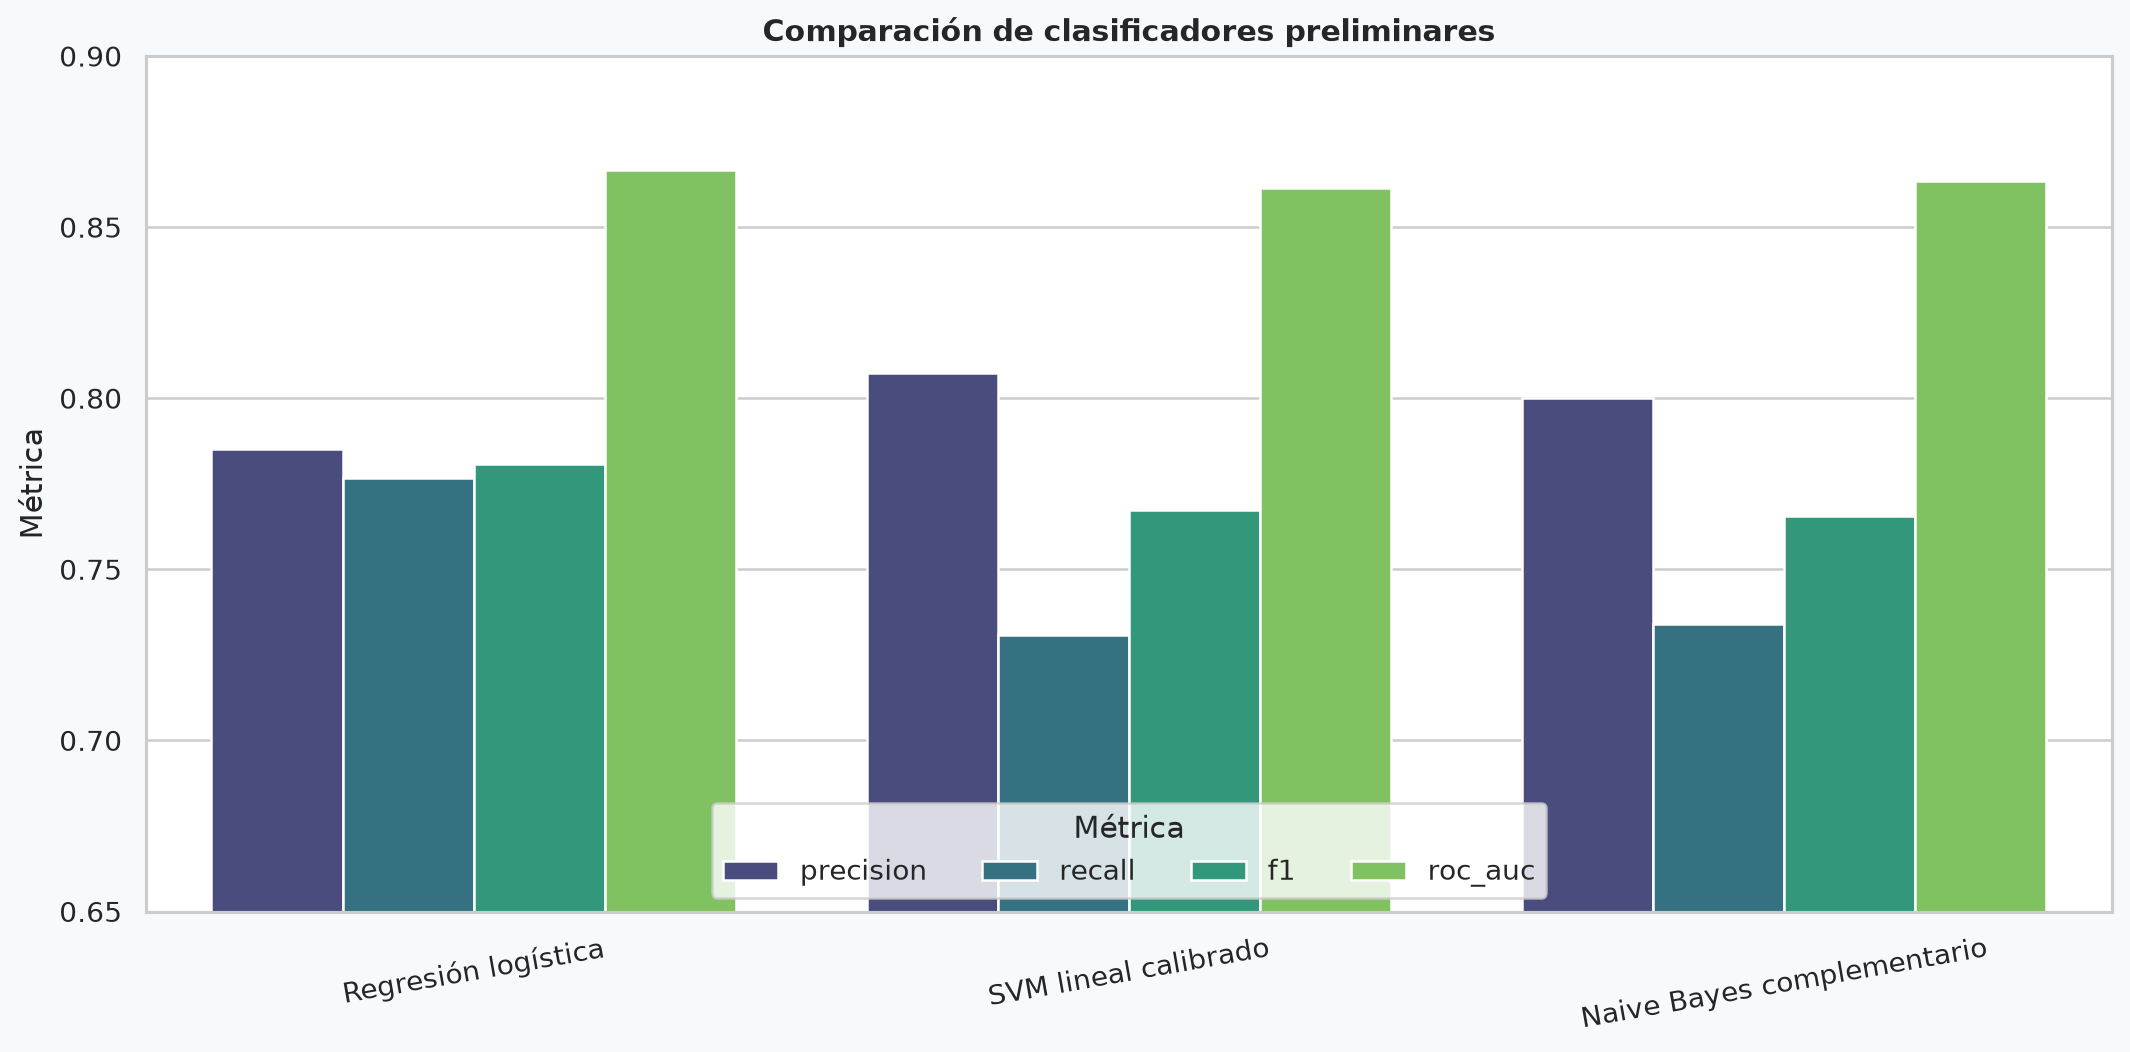

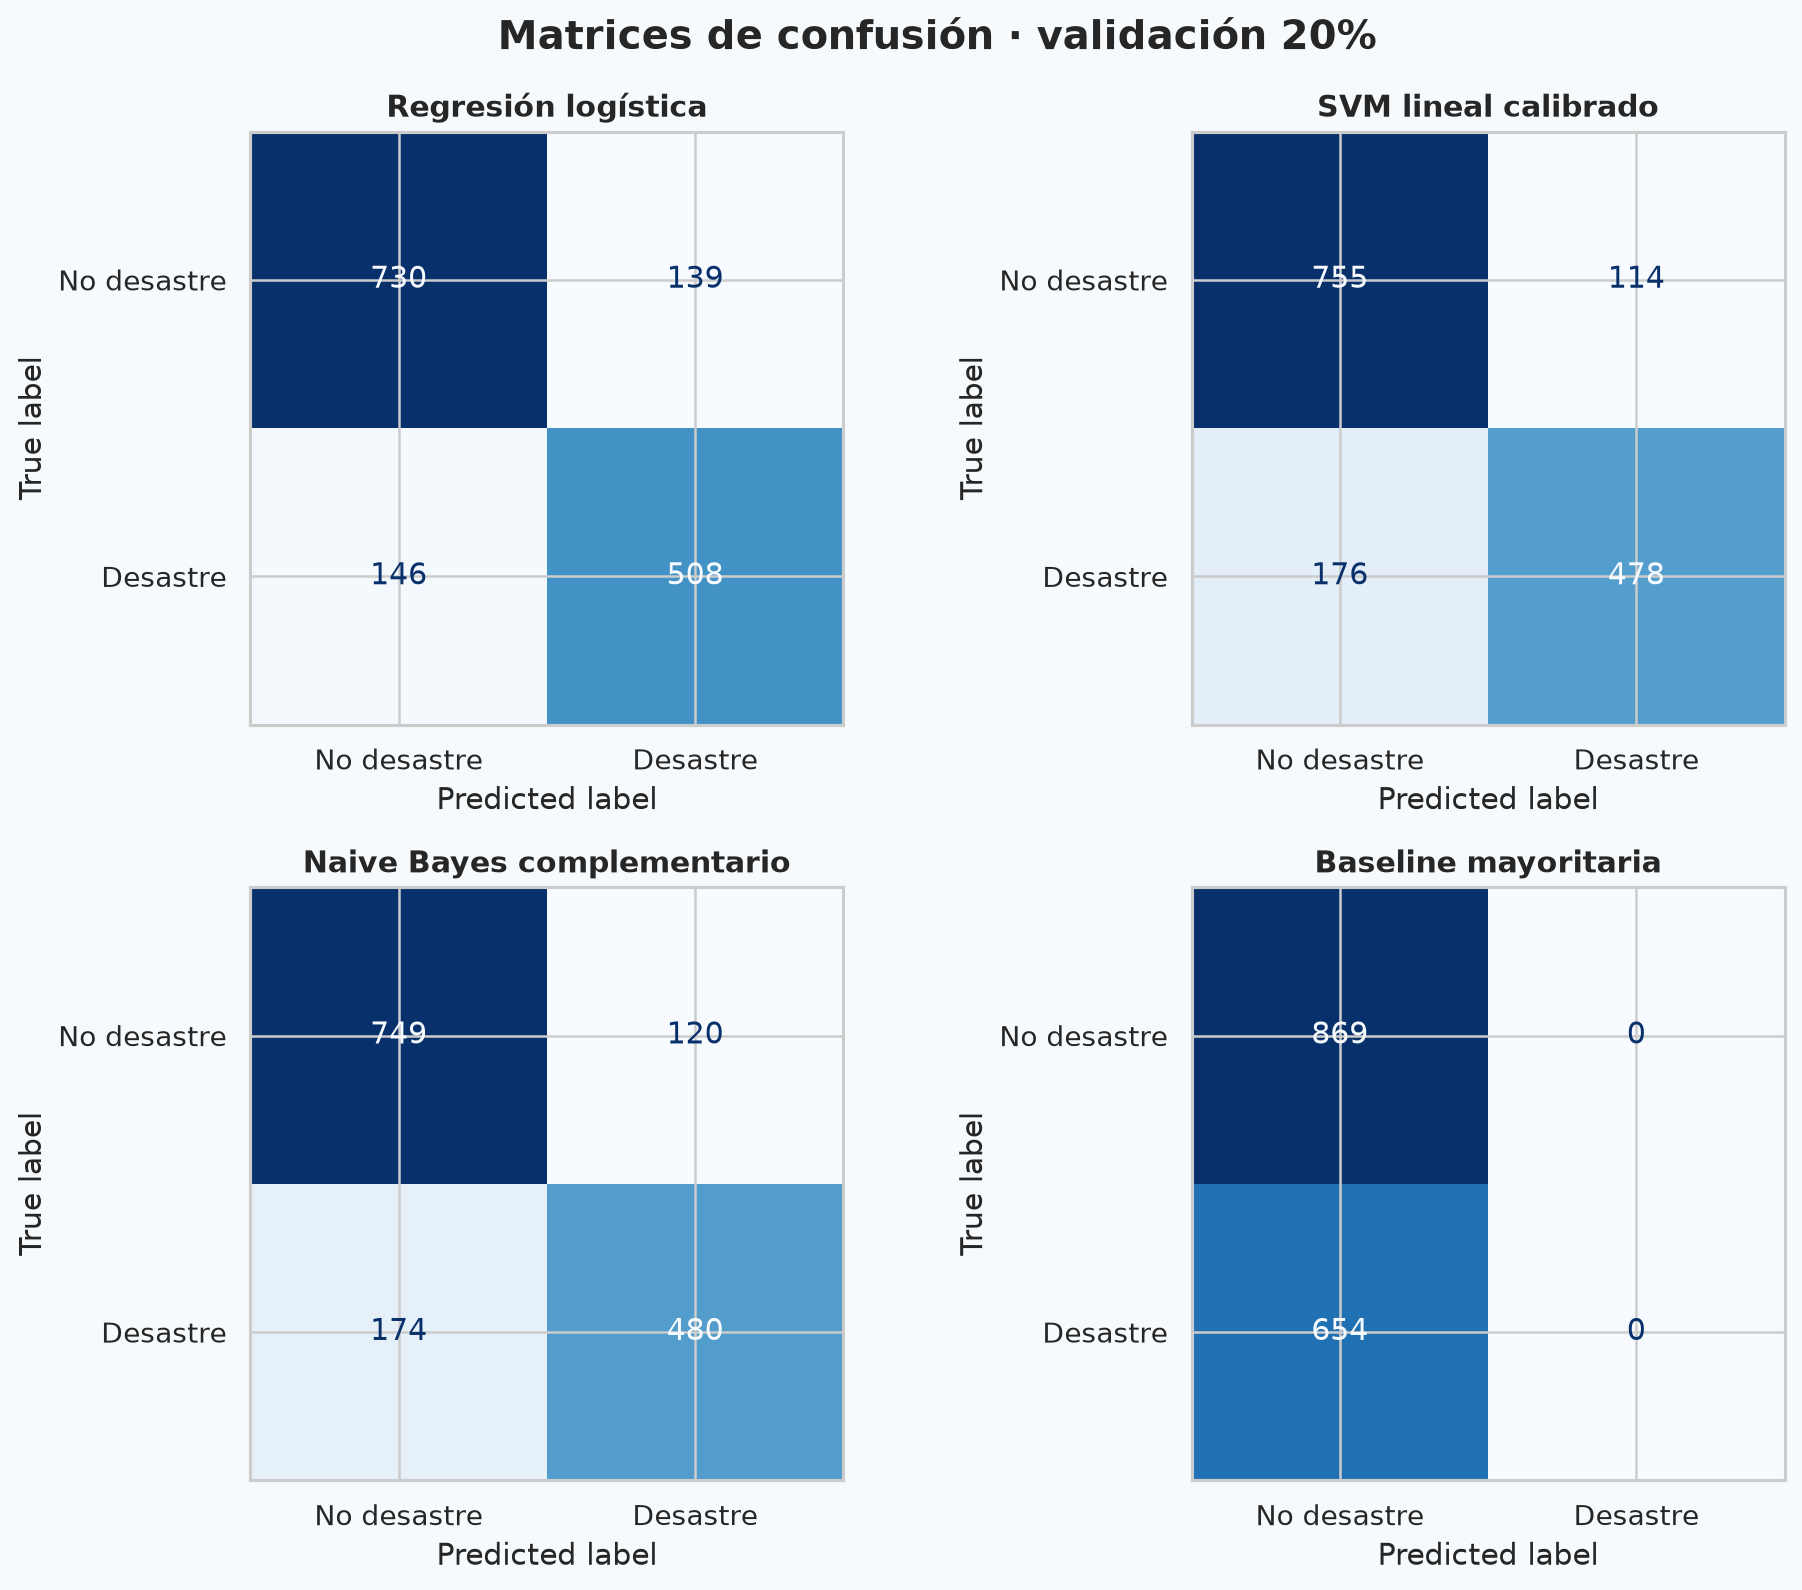

In [6]:
metrics = pd.read_csv(TABLES / "metricas_todos_los_modelos.csv")
cols = [c for c in ["modelo","usa_negatividad","accuracy","precision","recall","f1","f1_macro","roc_auc","tn","fp","fn","tp"] if c in metrics.columns]
show_table(metrics[cols])
display(Image(filename=str(FIGURES / "modelos_comparacion.png"), width=1000))
display(Image(filename=str(FIGURES / "modelos_matrices_confusion.png"), width=1000))

<div class="metric-grid">
 <div class="metric"><b>0.813</b><br>Exactitud</div><div class="metric"><b>0.781</b><br>F1 desastre</div>
 <div class="metric"><b>0.809</b><br>F1 macro</div><div class="metric"><b>0.867</b><br>ROC–AUC</div>
</div>

<div class="section"><h2>6 · Función de clasificación para texto crudo</h2></div>

La función final encapsula limpieza, transformación TF–IDF, predicción, probabilidad, sentimiento y negatividad. Así puede probarse con un texto nuevo sin preparar manualmente sus variables.

In [7]:
model = joblib.load(ROOT / "models" / "modelo_final.joblib")
analyzer = SentimentIntensityAnalyzer()
examples = [
    "Emergency services report a wildfire evacuation near the city",
    "That movie was a total disaster but we laughed all night 😂",
    "Flash flood warning: move to higher ground now!",
    "Lovely weather for the concert tonight :)"
]
predictions = pd.DataFrame([classify_raw_tweet(model, text, analyzer) for text in examples])
show_table(predictions)

texto,texto_limpio,clase,probabilidad_desastre,sentimiento,compound,negatividad
Emergency services report a wildfire evacuation near the city,emergency services report wildfire evacuation near city,Desastre real,0.962,negativo,-0.382,0.382
That movie was a total disaster but we laughed all night 😂,movie total disaster laughed night,No desastre,0.377,positivo,0.731,0.000
Flash flood warning: move to higher ground now!,flash flood warning higher ground,Desastre real,0.847,negativo,-0.400,0.400
Lovely weather for the concert tonight :),lovely weather concert tonight,Desastre real,0.549,positivo,0.778,0.000


<div class="section"><h2>7 · Sentimiento positivo, negativo y neutral</h2></div>

VADER asigna cuatro puntajes: negativo, neutral, positivo y `compound`. Se aplican los umbrales originales: positivo si `compound ≥ 0.05`, negativo si `compound ≤ −0.05` y neutral en el intervalo restante. Emoticonos, emojis, signos y mayúsculas permanecen disponibles para este análisis.

etiqueta,regla,fuente
positivo,compound >= 0.05,Hutto y Gilbert (2014)
negativo,compound <= -0.05,Hutto y Gilbert (2014)
neutral,-0.05 < compound < 0.05,Hutto y Gilbert (2014)


target,sentiment_label,tweets,porcentaje,categoria
0,negativo,1858,42.791,No desastre
0,neutral,1054,24.275,No desastre
0,positivo,1430,32.934,No desastre
1,negativo,1889,57.750,Desastre real
1,neutral,841,25.711,Desastre real
1,positivo,541,16.539,Desastre real


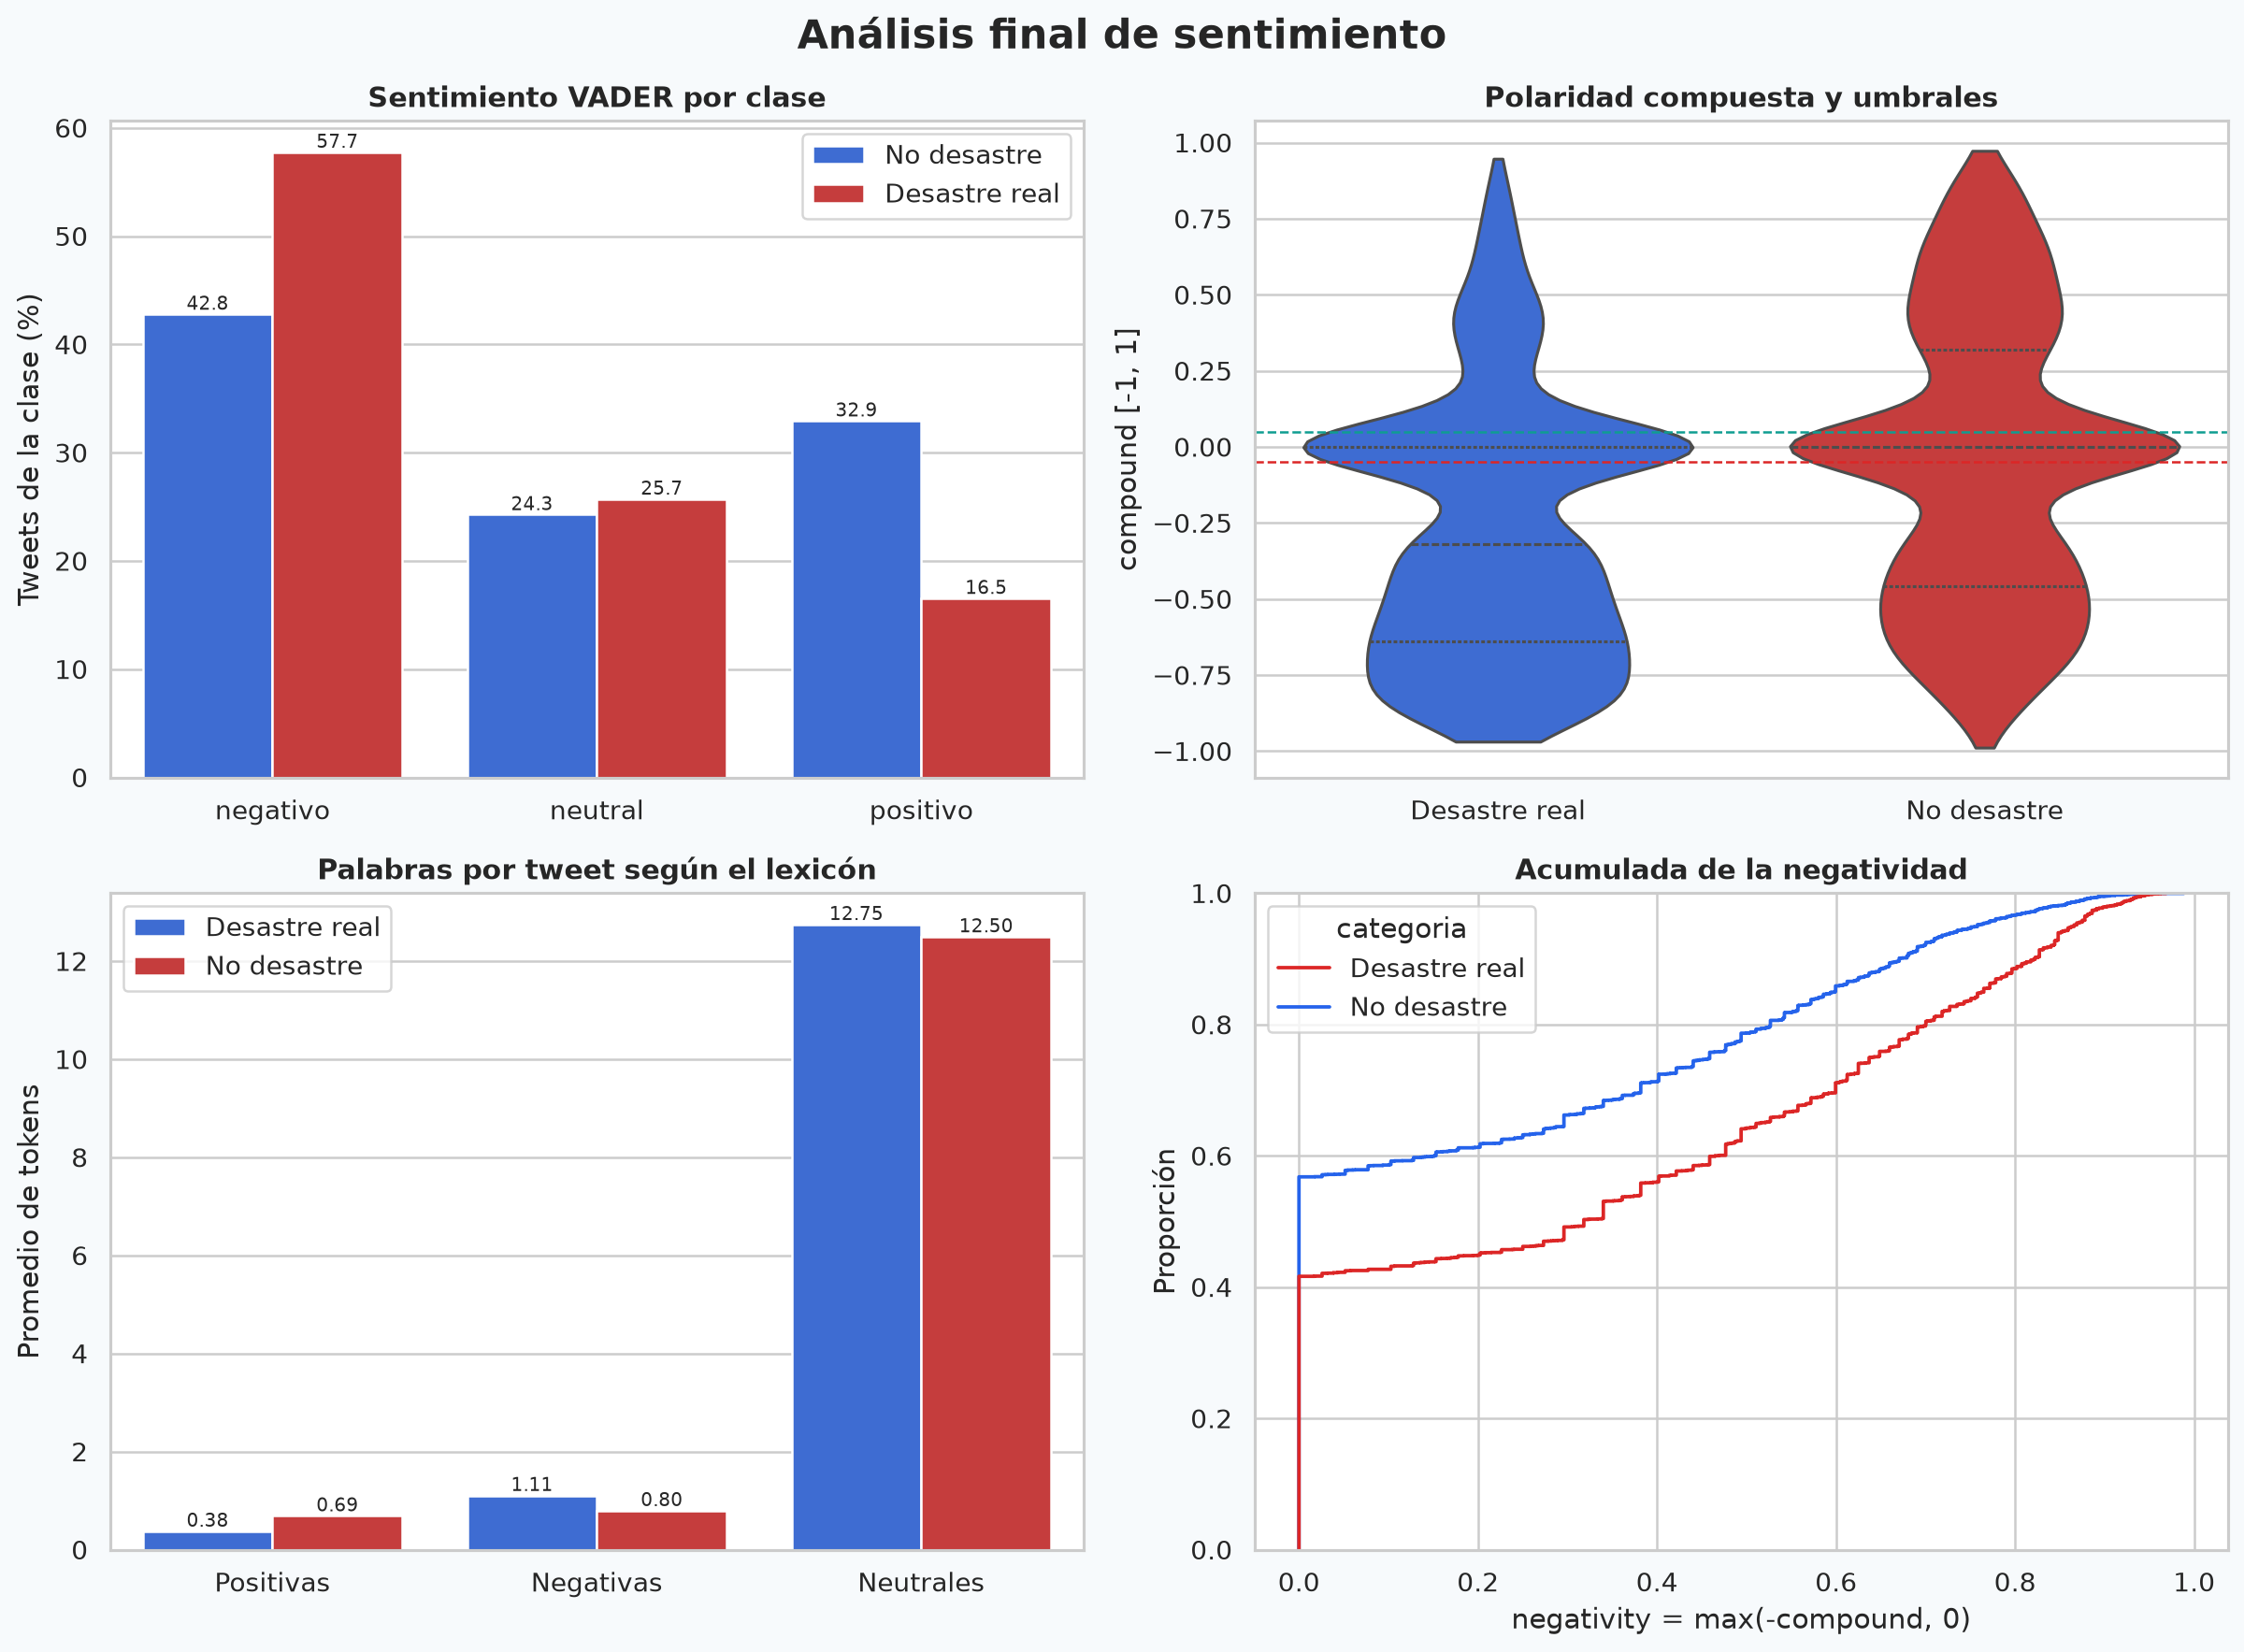

In [8]:
sentiment = pd.read_csv(TABLES / "sentimiento_distribucion.csv")
thresholds = pd.read_csv(TABLES / "sentimiento_umbrales.csv")
show_table(thresholds)
show_table(sentiment)
display(Image(filename=str(FIGURES / "sentimiento_final.png"), width=1000))

En el corpus completo se identifican 3,747 tweets negativos, 1,971 positivos y 1,895 neutrales. El sentimiento describe el tono del mensaje, pero no equivale a la etiqueta de desastre: un reporte factual puede ser neutral y una publicación no relacionada puede expresar fuerte negatividad.

<div class="section"><h2>8 · Diez tweets extremos y sus patrones</h2></div>

Diez tweets más positivos


id,categoria,sentiment_compound,text
10028,No desastre,0.973,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o1 I would Love Love Love!! To win
9345,No desastre,0.956,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!
8989,Desastre real,0.947,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.
8136,No desastre,0.943,@Zak_Bagans pets r like part of the family. I love animals.??? The last 2 pets I had I rescued! Breaks my heart when animals are mistreated????
4541,No desastre,0.942,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.
4844,No desastre,0.942,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.
9710,No desastre,0.939,Maaaaan I love Love Without Tragedy by @rihanna I wish she made the whole song
8994,No desastre,0.938,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favorite & Share
1453,No desastre,0.934,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.
9386,No desastre,0.934,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope for the good. There's hope ??????


Diez tweets más negativos


id,categoria,sentiment_compound,text
10689,No desastre,-0.988,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?
9172,Desastre real,-0.969,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead This is ridiculous
9166,Desastre real,-0.962,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl
9137,Desastre real,-0.960,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp
9782,No desastre,-0.956,@dramaa_llama but otherwise i will stay trapped as the worst lilourry stan ever AND without zarry what am I left with? NARRY. NO THANKS.
9159,Desastre real,-0.955,17 killed in SÛªArabia mosque suicide bombing A suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX
4213,No desastre,-0.955,at the lake *sees a dead fish* me: poor little guy i wonder what happened ashley: idk maybe it drowned wtf ????????
682,Desastre real,-0.954,illegal alien released by Obama/DHS 4 times Charged With Rape & Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4hF9GpO
2225,Desastre real,-0.952,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocaine Marijuana Heroine Kidnap Bust
9940,Desastre real,-0.949,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terrorist you sponsor terrorist.


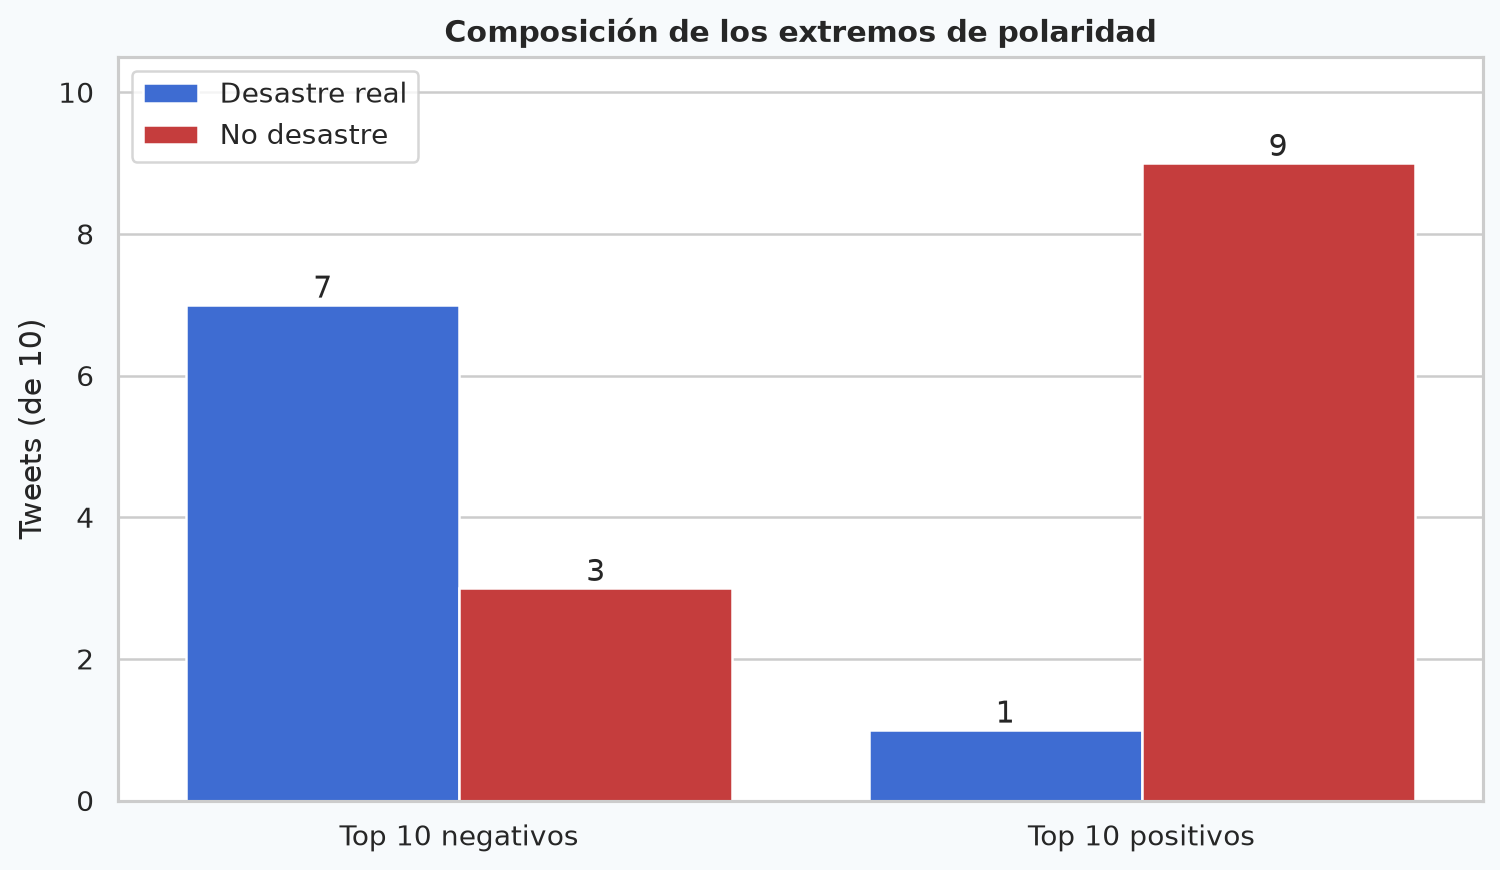

In [9]:
positive = pd.read_csv(TABLES / "top10_positivos.csv")
negative = pd.read_csv(TABLES / "top10_negativos.csv")
print("Diez tweets más positivos")
show_table(positive[["id","categoria","sentiment_compound","text"]])
print("Diez tweets más negativos")
show_table(negative[["id","categoria","sentiment_compound","text"]])
display(Image(filename=str(FIGURES / "top10_composicion.png"), width=700))

Siete de los diez extremos negativos corresponden a desastres, mientras que nueve de los diez extremos positivos no corresponden a desastres. Los extremos negativos concentran vocabulario de muerte, lesión, amenaza y destrucción; los positivos incluyen agradecimiento, humor, apoyo y lenguaje promocional. Esta composición respalda una relación entre clase y tono, pero también muestra excepciones suficientes para evitar una regla basada únicamente en sentimiento.

<div class="section"><h2>9 · ¿Los desastres son más negativos?</h2></div>

Se define `negativity = max(−compound, 0)`. Como la distribución contiene muchos ceros y no es normal, se usa Mann–Whitney bilateral. Se acompaña con diferencia de medias, intervalo bootstrap del 95% y delta de Cliff.

metrica,n_grupo_1,n_grupo_0,media_grupo_1,media_grupo_0,mediana_grupo_1,mediana_grupo_0,diferencia_medias,diferencia_medianas,u_statistic,p_valor_bilateral,p_valor_unilateral_mayor,cliffs_delta,magnitud_efecto,ic95_dif_medias_inferior,ic95_dif_medias_superior,ic95_dif_medianas_inferior,ic95_dif_medianas_superior
negativity,3271,4342,0.337,0.213,0.318,0.000,0.124,0.318,8570308.500,0.000,0.000,0.207,pequeño,0.110,0.138,0.296,0.340
sentiment_negative,3271,4342,0.183,0.137,0.167,0.098,0.046,0.070,8229475.000,0.000,0.000,0.159,pequeño,0.038,0.054,0.056,0.087
sentiment_compound,3271,4342,-0.266,-0.052,-0.318,0.000,-0.215,-0.318,5259347.000,0.000,1.000,-0.259,pequeño,-0.235,-0.194,-0.340,-0.296


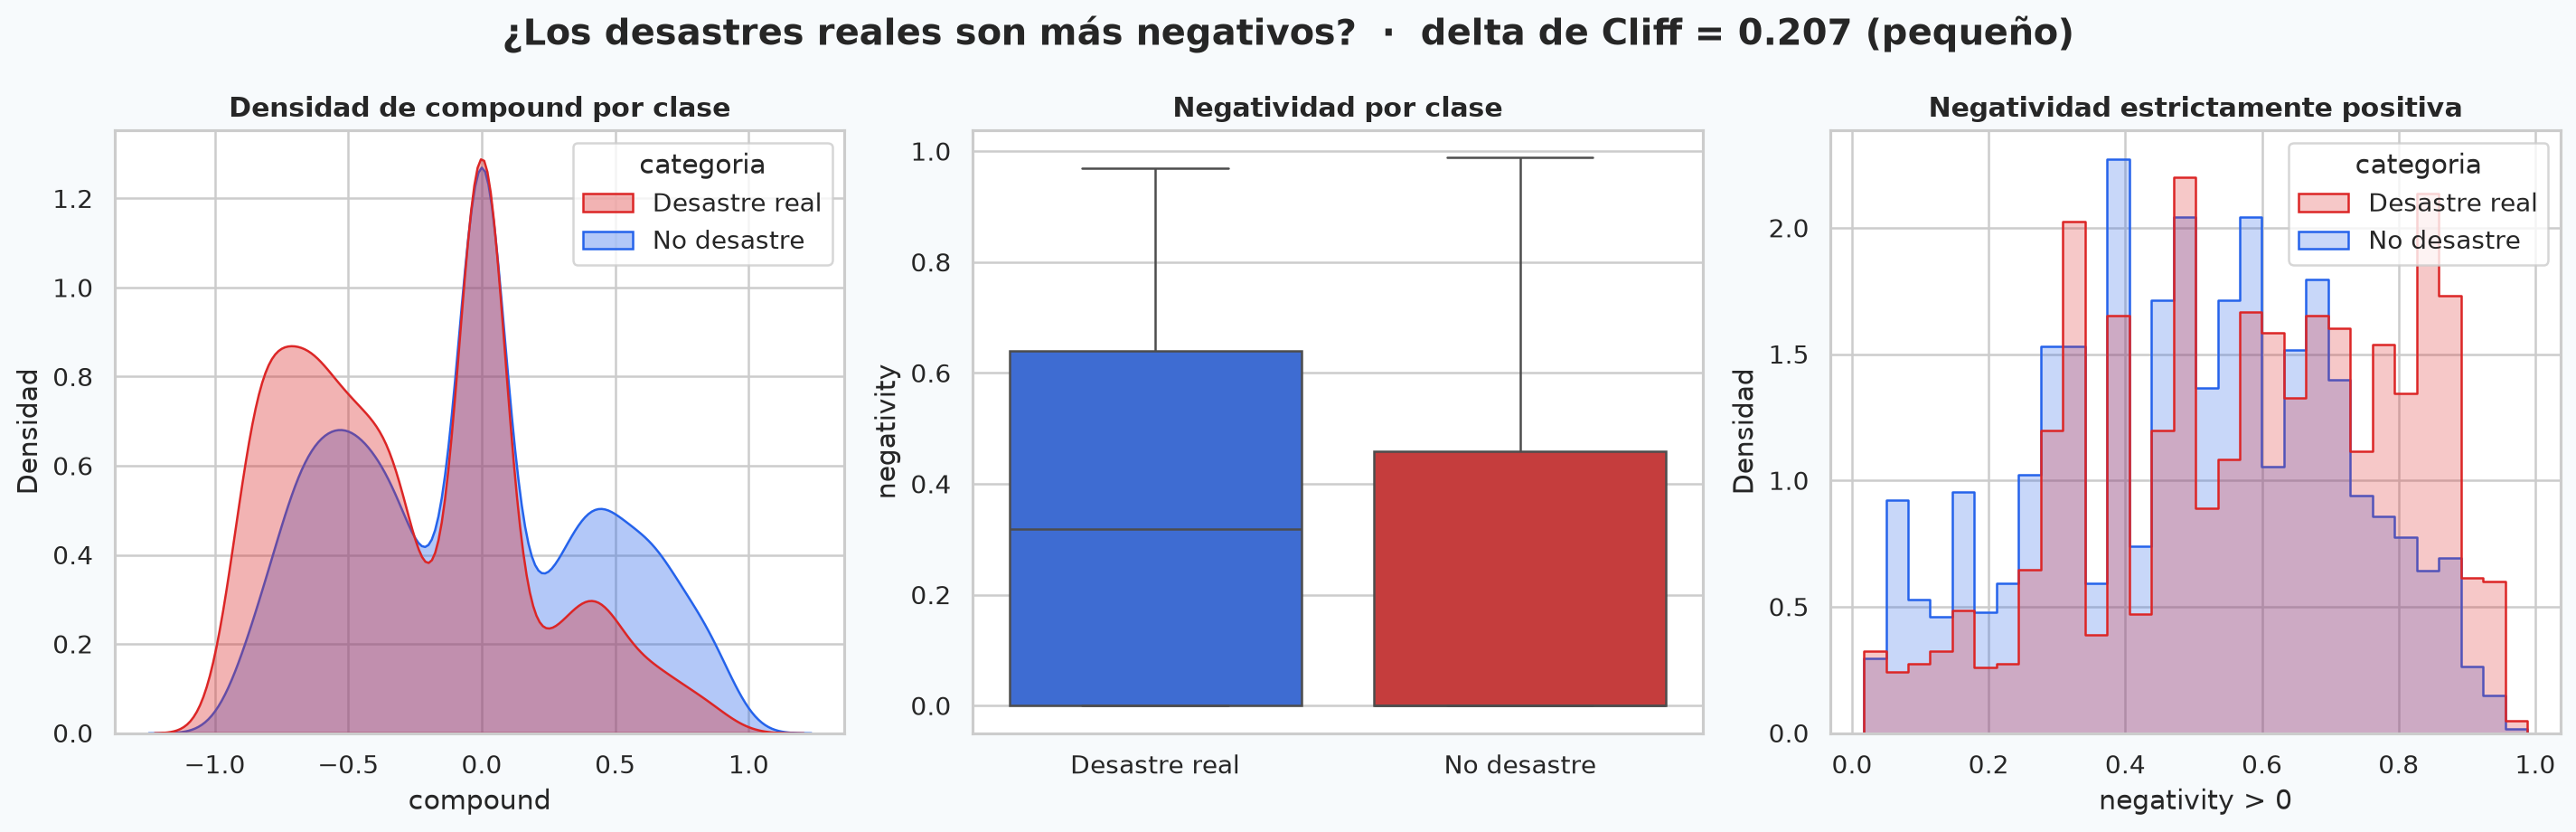

In [10]:
contrast = pd.read_csv(TABLES / "contraste_estadistico.csv")
show_table(contrast)
display(Image(filename=str(FIGURES / "contraste_negatividad.png"), width=1000))

<div class="insight"><b>Resultado.</b> La negatividad media es 0.337 en desastres y 0.213 en no desastres. La diferencia media es 0.124, con IC bootstrap 95% [0.110, 0.138]. La prueba produce <i>p</i> &lt; 0.001 y δ de Cliff = 0.207: existe evidencia clara de diferencia, pero el tamaño del efecto es pequeño.</div>

<div class="section"><h2>10 · Variable de negatividad y reentrenamiento</h2></div>

El modelo A usa solo TF–IDF; el modelo B agrega `negativity`. La partición, semilla y parámetros de regresión logística permanecen idénticos, de modo que cualquier diferencia pueda atribuirse a la nueva variable.

modelo,accuracy,precision,recall,f1,f1_macro,roc_auc,tn,fp,fn,tp,n_train,n_test,usa_negatividad
A · TF-IDF sin negatividad,0.813,0.785,0.777,0.781,0.809,0.867,730,139,146,508,6090,1523,False
B · TF-IDF con negatividad,0.798,0.766,0.761,0.764,0.793,0.867,717,152,156,498,6090,1523,True


metrica,modelo_a_sin_negatividad,modelo_b_con_negatividad,diferencia_absoluta,sentido
accuracy,0.813,0.798,-0.015,empeora
precision,0.785,0.766,-0.019,empeora
recall,0.777,0.761,-0.015,empeora
f1,0.781,0.764,-0.017,empeora
f1_macro,0.809,0.793,-0.015,empeora
roc_auc,0.867,0.867,0.000,mejora
tn,730.000,717.000,-13.000,empeora
fp,139.000,152.000,13.000,empeora
fn,146.000,156.000,10.000,empeora
tp,508.000,498.000,-10.000,empeora


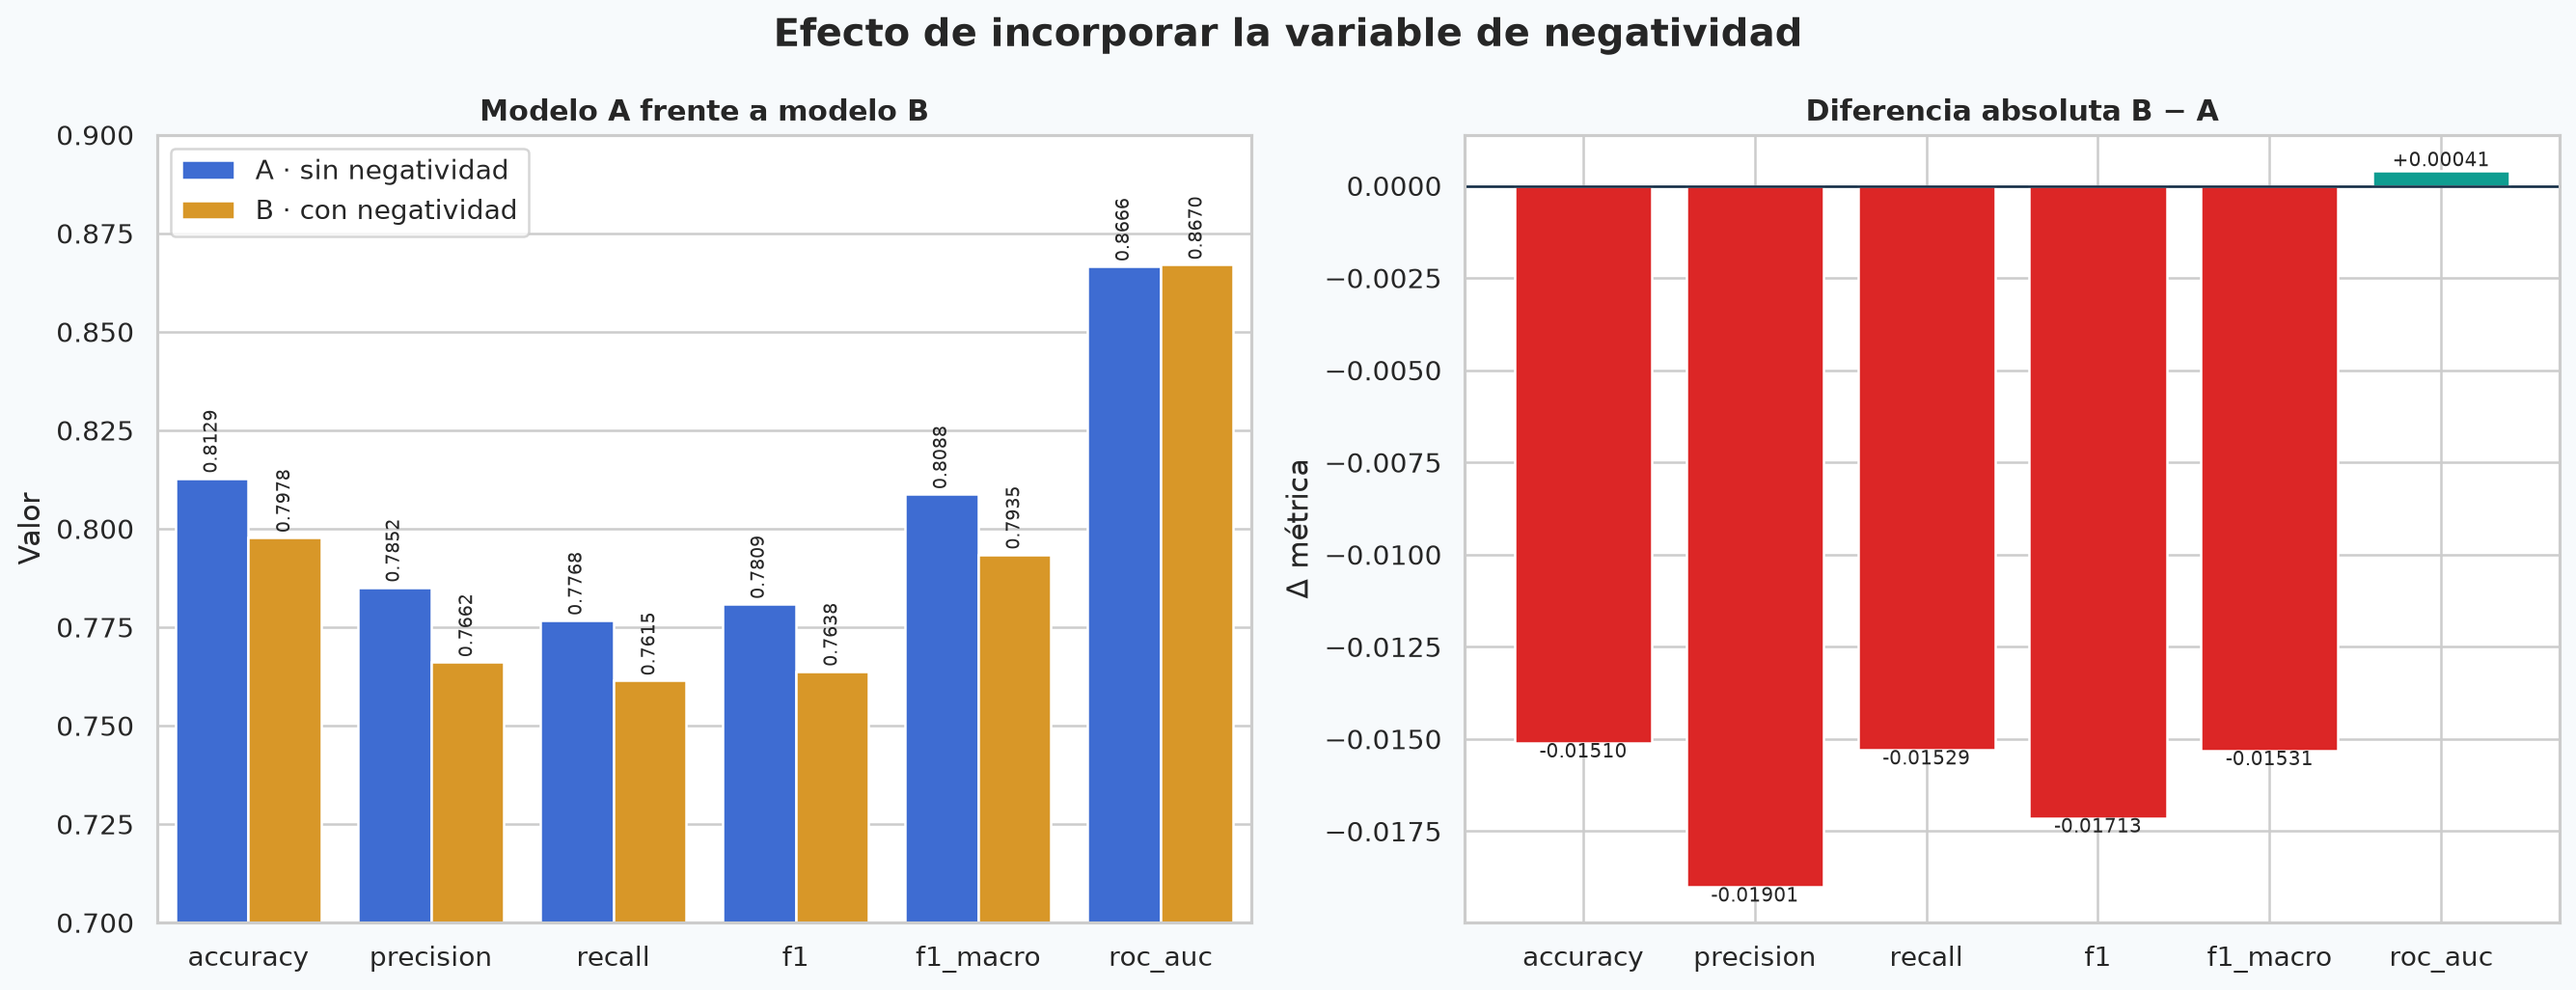

In [11]:
comparison = pd.read_csv(TABLES / "comparacion_negatividad_metricas.csv")
deltas = pd.read_csv(TABLES / "comparacion_negatividad_diferencias.csv")
show_table(comparison)
show_table(deltas)
display(Image(filename=str(FIGURES / "comparacion_negatividad.png"), width=1000))

La negatividad aumenta ROC–AUC en apenas 0.0004, pero reduce exactitud en 0.0151, recall en 0.0153 y F1 en 0.0171; además agrega 13 falsos positivos y 10 falsos negativos. Por lo tanto, no se incorpora al modelo definitivo. El resultado negativo del experimento es informativo: una variable puede diferir significativamente entre grupos y aun así no aportar señal incremental a un modelo que ya representa el texto.

<div class="section"><h2>11 · Modelo final y análisis de errores</h2></div>

,valor
modelo,A · TF-IDF sin negatividad
familia,reentrenamiento
usa_negatividad,False
regla_seleccion,Máximo F1 de la clase desastre; ROC-AUC desempata si la brecha de F1 < 0.002
justificacion,"F1 de la clase desastre = 0.780938, superior en 0.017134 al siguiente candidato; la brecha excede la toler..."
candidatos_evaluados,"[A · TF-IDF sin negatividad, B · TF-IDF con negatividad]"
familia_base_elegida,Regresión logística
familia_base_criterio,Mejor F1 de la clase desastre entre los cuatro modelos preliminares (0.780938)
variables,"{'texto': 'clean_text (limpieza de clasificación sobre el tweet crudo)', 'numerica': None}"
parametros,"{'tfidf': {'ngram_range': [1, 2], 'min_df': 2, 'max_df': 0.98, 'sublinear_tf': True, 'max_features': 35000..."


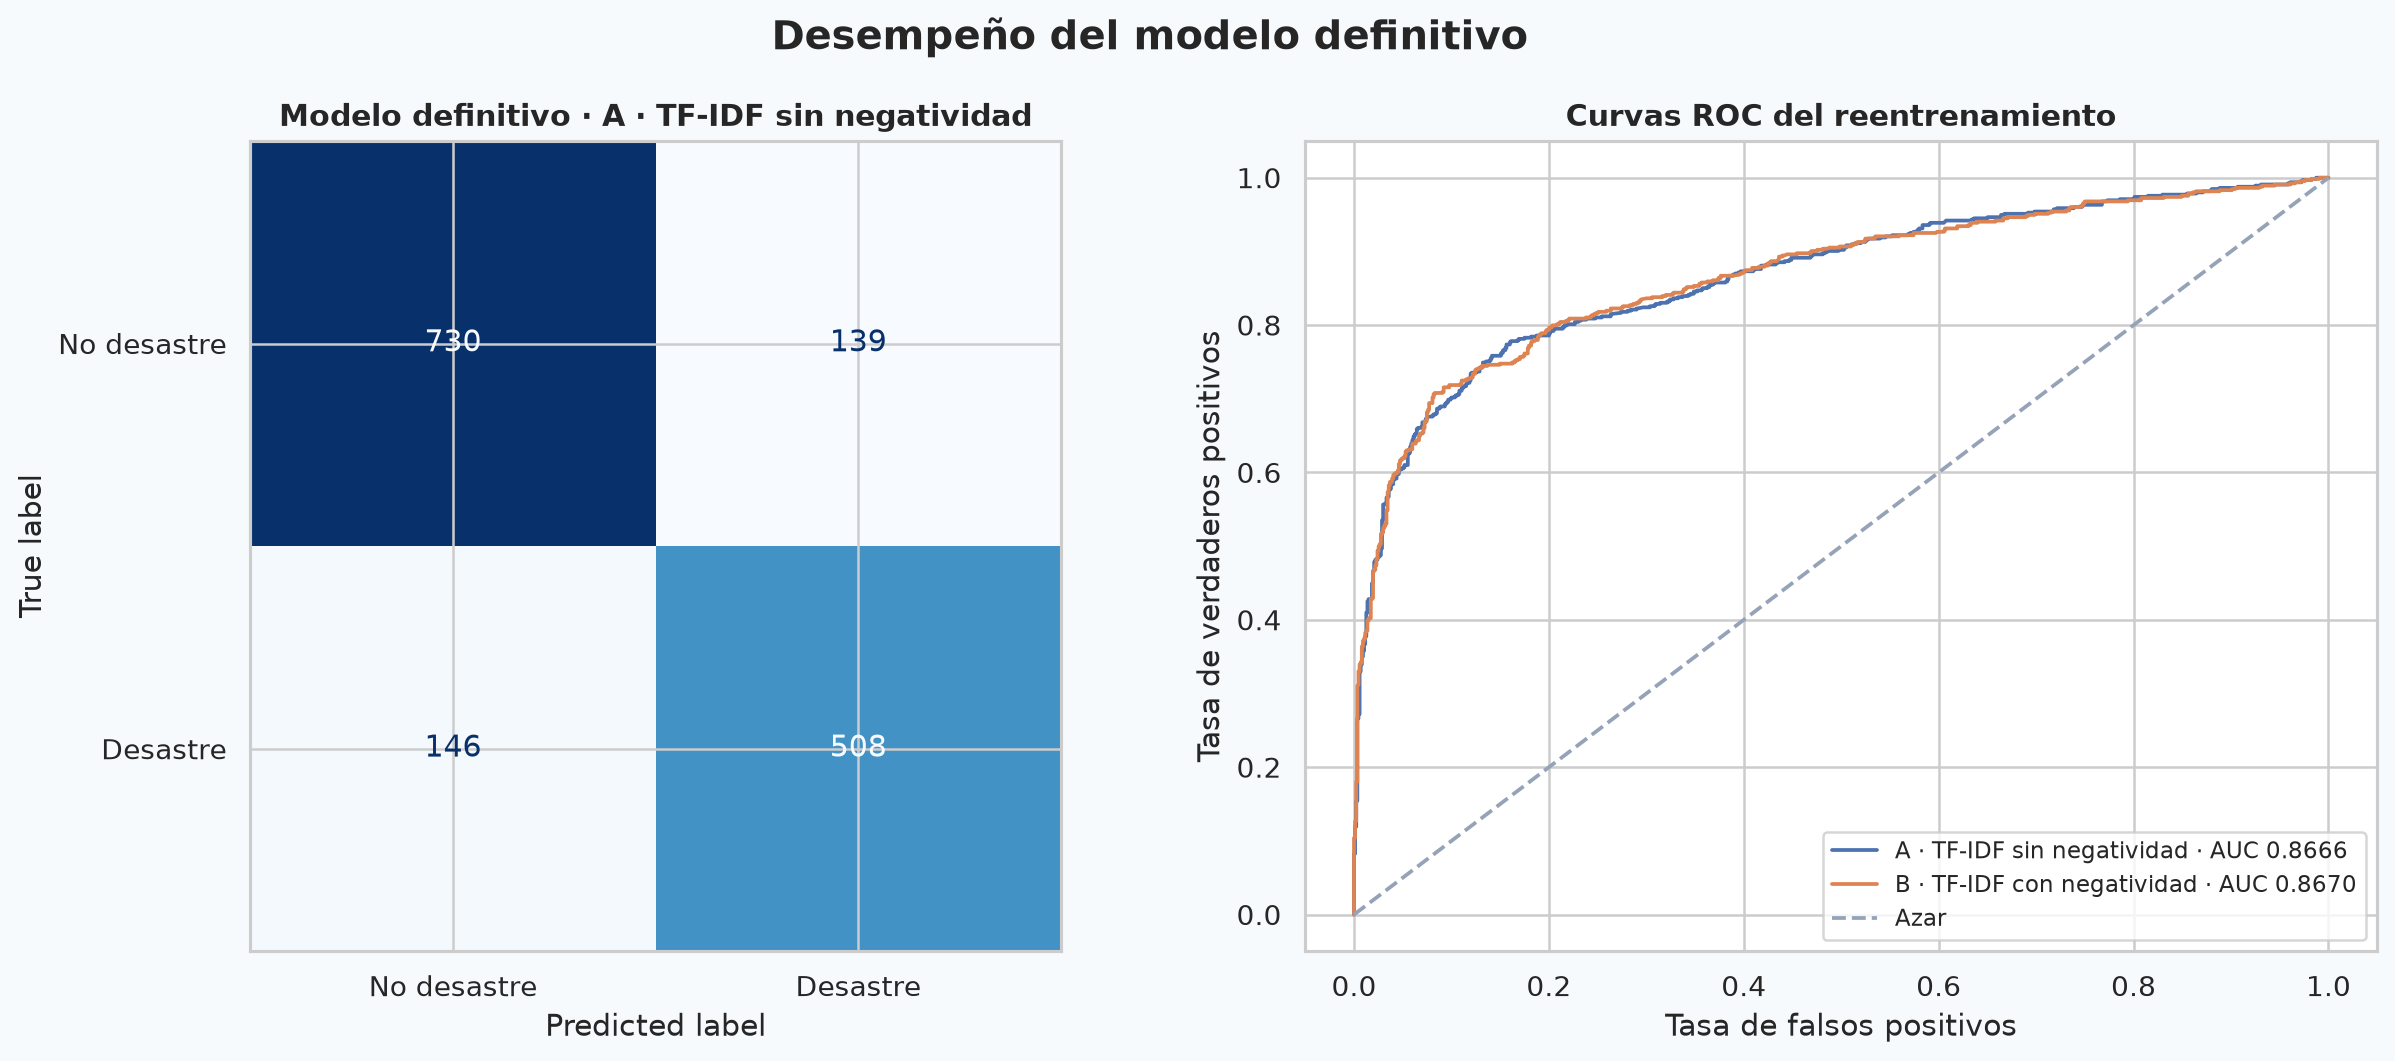

Falsos positivos: 139 · Falsos negativos: 146


tipo_error,sentiment_label,negativity,probabilidad_desastre,text
Falso negativo,negativo,0.334,0.070,You can never escape me. Bullets don't harm me. Nothing harms me. But I know pain. I know pain. Sometimes I share it. With someone like you.
Falso negativo,positivo,0.000,0.077,Do you feel like you are sinking in low self-image? Take the quiz: http://t.co/bJoJVM0pjX http://t.co/wHOc7LHb5F
Falso negativo,neutral,0.000,0.084,@PianoHands You don't know because you don't smoke. The way to make taxis and buses come is to light a cigarette to smoke while you wait.
Falso negativo,negativo,0.583,0.086,Bloody insomnia again! Grrrr!! #Insomnia
Falso negativo,positivo,0.000,0.097,@UnrealTouch fuck sake john Jesus my heart just sunk.
Falso negativo,negativo,0.548,0.099,I just watched emmerdale nd I don't know who most of them are but a slightly attractive man named Ross just got beat up nd now he's dead
Falso negativo,negativo,0.700,0.110,Black Eye 9: A space battle occurred at Star M27329 involving 1 fleets totaling 1236 ships with 7 destroyed
Falso negativo,positivo,0.000,0.114,I can't drown my demons they know how to swim
Falso negativo,neutral,0.000,0.121,Chick masturbates a guy until she gets exploded on her face > http://t.co/5QhoeHE9hf
Falso negativo,neutral,0.000,0.129,@Yankees body bagging mfs


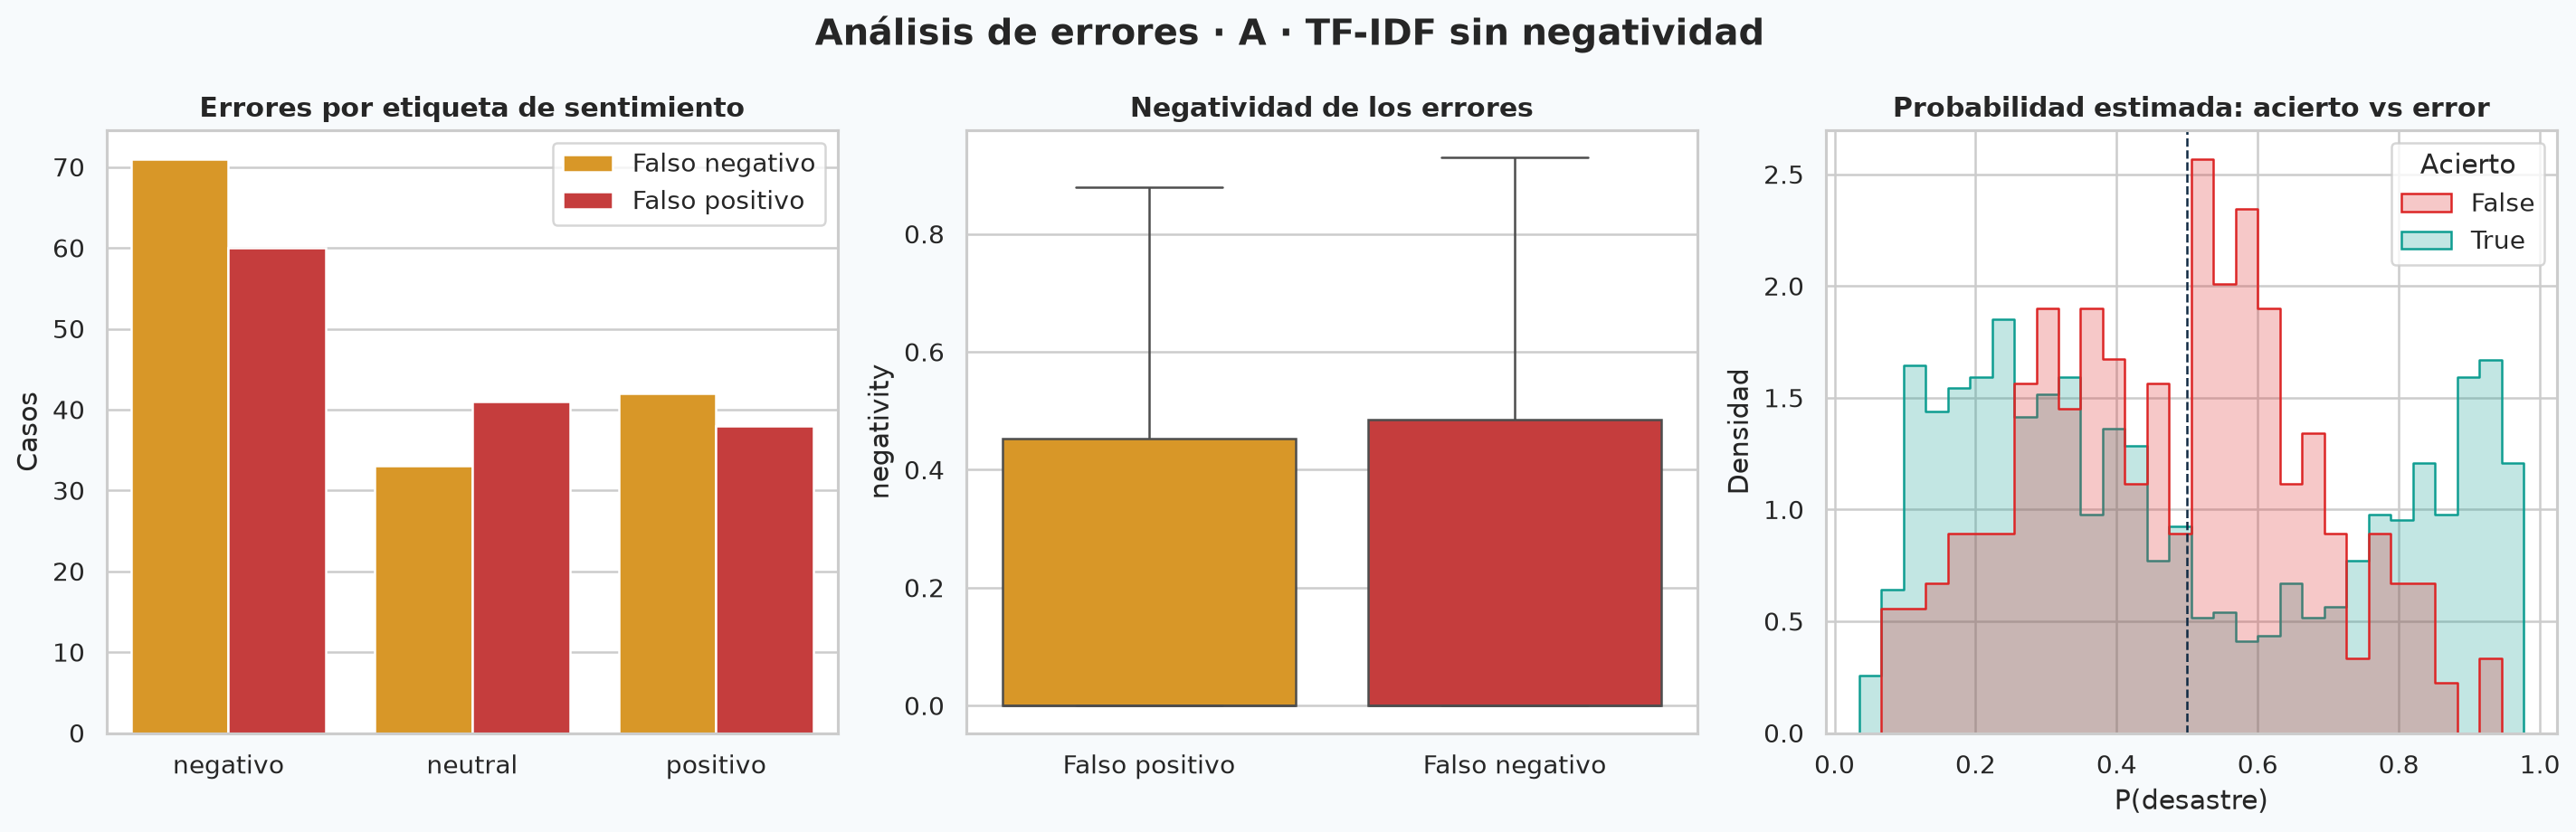

In [12]:
metadata = json.loads((ROOT / "models" / "metadata_final.json").read_text(encoding="utf-8"))
display(pd.DataFrame([metadata]).T.rename(columns={0:"valor"}))
display(Image(filename=str(FIGURES / "modelo_final.png"), width=900))
errors = pd.read_csv(TABLES / "analisis_errores.csv")
print(f"Falsos positivos: {(errors['tipo_error'] == 'Falso positivo').sum()} · Falsos negativos: {(errors['tipo_error'] == 'Falso negativo').sum()}")
show_table(errors[["tipo_error","sentiment_label","negativity","probabilidad_desastre","text"]].head(15))
display(Image(filename=str(FIGURES / "analisis_errores.png"), width=1000))

Los 139 falsos positivos suelen contener terminología alarmante en contextos figurados, humorísticos o promocionales. Los 146 falsos negativos incluyen mensajes breves, ubicaciones implícitas y reportes que describen hechos con tono neutral. Esto evidencia límites del modelo bolsa-de-palabras: no comprende ironía, temporalidad ni conocimiento del mundo.

### Conclusiones

1. Los n-gramas aportan contexto suficiente para superar ampliamente el baseline sin recurrir a modelos opacos.
2. La regresión logística con TF–IDF logra el mejor compromiso y queda seleccionada como modelo final.
3. Los tweets de desastre son, en promedio, más negativos; la diferencia es significativa pero de tamaño pequeño.
4. La negatividad no mejora la clasificación cuando se añade a TF–IDF, por lo que se descarta del modelo definitivo.
5. El desempeño debe interpretarse con cautela: el corpus proviene de una competencia, VADER está diseñado para inglés y la validación corresponde a una sola partición estratificada.

### Reproducibilidad y evidencia

In [13]:
evidence = pd.read_csv(TABLES / "evidencia_rubrica.csv")
show_table(evidence)
print("Modelo final:", (ROOT / "models" / "modelo_final.joblib").exists())
print("Metadatos:", (ROOT / "models" / "metadata_final.json").exists())
print("Semilla:", summary["particion"]["semilla"])

criterio,puntos,evidencia,generado,faltantes
EDA,15,outputs/figures/eda_panorama.png; outputs/tables/eda_por_clase.csv,sí,nan
Limpieza y preprocesamiento,10,outputs/tables/auditoria_limpieza.csv; outputs/tables/ejemplos_preprocesamiento.csv,sí,nan
"N-gramas, frecuencias y probabilidades",10,outputs/tables/unigramas_target_1.csv; outputs/tables/bigramas_target_1.csv; outputs/tables/trigramas_target_1.csv,sí,nan
Modelos clasificadores,15,outputs/tables/metricas_todos_los_modelos.csv; outputs/figures/modelo_final.png,sí,nan
Función de clasificación,20,outputs/tables/ejemplos_funcion_final.csv; scripts/predict_tweet.py; models/modelo_final.joblib; models/metadata_final.json,sí,nan
Sentimiento positivo/negativo/neutral,10,outputs/tables/sentimiento_distribucion.csv; outputs/figures/sentimiento_final.png,sí,nan
Variable de negatividad,5,outputs/tables/negatividad_definicion.csv; outputs/tables/comparacion_negatividad_diferencias.csv,sí,nan
Resultados y discusión,15,outputs/tables/analisis_errores.csv; outputs/tables/contraste_estadistico.csv; reports/informe_final.pdf; notebooks/Lab5_Completo.ipynb,sí,nan


Modelo final: True
Metadatos: True
Semilla: 42


### Referencias

- Hutto, C. J. y Gilbert, E. (2014). *VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text*. ICWSM.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.
- Salton, G. y Buckley, C. (1988). *Term-weighting approaches in automatic text retrieval*. Information Processing & Management, 24(5), 513–523.
- Kaggle. *Natural Language Processing with Disaster Tweets*. https://www.kaggle.com/competitions/nlp-getting-started
- Scikit-learn Developers. *Working With Text Data*. https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html

<div class="footer">Laboratorio 5 · Grupo 1 · Data Science, Sección 10 · Entrega final reproducible</div>